In [1]:
import sys

sys.path.append("../training_data")

In [2]:
from utils.utils import *

# structures_path = "1.Minimal_structures/Minimal_structures"

# Cif.path = structures_path
# Cif.original_cifs_path = "/home/fnerin/Desktop/allodb_new/src/data" # <pdb>_updated.cif.gz

# Functions

## Get representative's sites annos

Dictionary with the site's residues, modulators, chains, and its uniprots. For each uniprot, the corresponding site residues, chains and its residues, and range.

In [3]:
def get_sites_ups(p, sites):
    sites_ups = {}
    for sid, site in sites.items():
        # The annotation is based on Uniprots, so equivalent sites of the site are assumed to have the same Uniprots
        site_res = site["site"]

        # Skip site if any of the chains of the site do not have more than 3 Uniprot-associated residues participating in it
        if any(
            len(ares.query("pdbx_sifts_xref_db_acc != '?'")) < 3 
            for aid, ares in site_res.groupby("label_asym_id")
        ):
            continue

        # For each Uniprot in the site, annotate the chain IDs, the residues of the site and of the chains (that have Uniprots) and the min-max of the Uniprot
        site_ups = {}
        for u, ures in site_res.query("pdbx_sifts_xref_db_acc != '?'").groupby("pdbx_sifts_xref_db_acc"):
            asym_ids = ures.label_asym_id.unique().tolist()
            chains_res = p.residues.query(f"label_asym_id in {asym_ids} and pdbx_sifts_xref_db_acc == '{u}'") # maybe simplify
            site_ups[u] = {
                "ulabel_asym_id": asym_ids, 
                "usiteres": ures,
                "ures": chains_res,
                "umin": chains_res.pdbx_sifts_xref_db_num.astype(int).min(),
                "umax": chains_res.pdbx_sifts_xref_db_num.astype(int).max()
            }
        if len(site_ups) == 0: continue

        sites_ups[sid] = {
            "siteres": site_res,
            "label_asym_id": site_res.query("pdbx_sifts_xref_db_acc != '?'").label_asym_id.unique().tolist(),
            "uniprots": site_ups,
            "modulator": site['mod'].label_asym_id.unique().tolist()
        }
        
    return sites_ups

## Detect ligands close to site

Any elements closer than 6A from the center of geometry of a passed site to detect true apos.

In [4]:
import pymol2

def get_apo_ligands(newpdb, newp, site, threshold=6):
     # Define the PyMOL-style selection of the modulator residues
    sele = " or ".join(
        f"{res['label_asym_id']}/{res['auth_asym_id']}/{res['auth_comp_id']}`{res['auth_seq_id']}{res['pdbx_PDB_ins_code'].replace('?', '')}/*"
        for i, res in site.iterrows()
    )

    with pymol2.PyMOL() as pymol, newp.cif.ciff() as f:
        pymol.cmd.feedback(
            "disable", "executive", "details"
        )  # to silence "ExecutiveLoad-Detail: Detected mmCIF"
        pymol.cmd.load(f.name)

        # Crete a pseudoatom in the center of mass of the site's residues
        pymol.cmd.pseudoatom("pa", selection=sele)

        # Retrieve all atoms within the threshold of the selection
        atoms = pymol.cmd.get_model(f"(br. all within {threshold} of pa) and not (pa or {sele})")
        
    # Process the atom selection to obtain residue identifiers
    residue_ids = set(
        tuple(
            (
                a.segi, a.chain, a.resn,
                a.resi_number, a.ins_code or '?' # pdbx_PDB_ins_code or "?" if none
            ) 
            for a in atoms.atom
        )
    )

    # Transform the PyMOL-derived residue identifiers into a standard table of residues that can be used to retrieve the rows/residues from the parent structure's .residues table    
    residues = (
        newp.residues.merge(
            pd.DataFrame(
                residue_ids,
                columns=[
                    "label_asym_id", "auth_asym_id", "auth_comp_id",
                    "auth_seq_id", "pdbx_PDB_ins_code"
                ],
                dtype=str
            )
        )
        .query("auth_comp_id != 'HOH'")
        .query(f"label_asym_id not in {site.label_asym_id.unique().tolist()}")
    )

    # If there are any residues
    if len(residues) > 0:
        # Get the cif field with entity data        
        edata = pd.DataFrame(newpdb.cif.data["_entity"], dtype=str)
        
        # Get dictionaries of the info of only non-polymer items
        ligands = [
            e
            for e in (
                edata
                .query(f"id in {residues.label_entity_id.unique().tolist()}")[
                    ["pdbx_description", "type"]
                ].to_dict("records")
            )
        ]
        
        ions = all(e["pdbx_description"].lower().endswith(" ion") for e in ligands)

        # Return the info
        if ions: # if found molecules is all ions: no lig
            return {
            ("apo", "has_lig"): False,
            ("apo", "lig_types"): ["ion",],
            ("apo", "lig"): residues
        }
        else: #
            return {
                ("apo", "has_lig"): True,
                ("apo", "lig_types"): list(set(e["type"] for e in ligands)),
                ("apo", "lig"): residues
            }
    else:
        return {("apo", "has_lig"): False}

## Check overlaps in a new putative apo pdb

In [5]:
from utils.new_pdbs import Pdb
import numpy as np
import gzip

In [6]:
def check_pdb(newpdb, pdb, sites_ups, ups):
    newpdb = Pdb(newpdb.lower())

    # If the new PDB doesn't have a column for Uniprotts or doesn't have all Uniprots of holo, skip
    if "pdbx_sifts_xref_db_acc" not in newpdb.residues.columns: return
    if not all(u in newpdb.residues.pdbx_sifts_xref_db_acc.unique() for u in ups): return

    # Use structure of the assembly if it's different from the model and it isn't repetition-based
    newp = newpdb
    try:
        if newpdb.assembly is not None and newpdb.assembly._repetitions is None:
            newp = newpdb.assembly
    except: # fix/patch for structures with multiple models to use only first
        with newpdb._extended_temp_ciff({
            "_atom_site": newpdb.atoms.query("pdbx_PDB_model_num == '1'").to_dict(orient="list")
        }) as f:
            newpdb.cif._cif_content = gzip.compress(f.read().encode())
        if newpdb.assembly is not None and newpdb.assembly._repetitions is None:
            newp = newpdb.assembly
    # we assume that all sites_uniprots are going to be found in the pdb, AND:
    # we don't care that the chains with the ups of interest have other ups (chimeras)

    # Check each Uniprot-based site for overlaps
    for sid, site in sites_ups.items():
        # Obtain the residues of the Uniprot-based site in the new structure, and skip if not found
        merged_site = (
            newp.residues
            .query(f"pdbx_PDB_model_num == '1'")
            .merge(
                site["siteres"],
                on=['pdbx_sifts_xref_db_acc', 'pdbx_sifts_xref_db_num'],
                suffixes = (None, '_del')
            )
            .loc[:, lambda x: [c for c in x if not c.endswith("_del")]]
        )
        if len(merged_site) == 0:
            continue

        # Get the ligands found in the correspnding Uniprot-based site, if any
        ligands = {
            asym_id: get_apo_ligands(newpdb, newp, merged_siteres)
            for asym_id, merged_siteres in merged_site.groupby("label_asym_id")
        }

        # Create the base Uniprot-site dictionary with the holo information
        sd = {
            ("allodb", "pdb"): pdb.entry_id,
            ("allodb", "site_id"): sid,
            ("allodb", "label_asym_id"): site["label_asym_id"],
            ("allodb", "mod"): site["modulator"],
            ("allodb", "siteres"): site["siteres"],
        }
        # Create the base Uniprot-site dictionary with the apo information at the whole-site level
        apo_sd = {
            ("apo", "site"): round(
                (
                    len( merged_site[['pdbx_sifts_xref_db_acc', 'pdbx_sifts_xref_db_num']].drop_duplicates() ) 
                    / len( site["siteres"][['pdbx_sifts_xref_db_acc', 'pdbx_sifts_xref_db_num']].drop_duplicates() )
                ),               
                2
            ),
            ("apo", "siteres"): merged_site,
            ("apo", "any_apo_chain"): any(not c[("apo", "has_lig")] for c in ligands.values()),
            ("apo", "ligands"): ligands,
        }
        # Yield a dictinary for each Uniprot on the original Uniprot-site, containing sd and apo_sd together with other Uniprot-specific information
        for u, ud in site["uniprots"].items():
            d = sd.copy()

            # Obtain the Uniprot residues of the structure and calculate chain and site overlaps
            ures = newp.residues.query(f"pdbx_sifts_xref_db_acc == '{u}' and pdbx_PDB_model_num == '1'")
            if len(ures) == 0:
                break
            umin, umax = ures.pdbx_sifts_xref_db_num.astype(int).min(), ures.pdbx_sifts_xref_db_num.astype(int).max()
            usite = ures.merge(
                ud["usiteres"], 
                on=['pdbx_sifts_xref_db_acc', 'pdbx_sifts_xref_db_num'],
                suffixes = (None, '_del')
            ).loc[:, lambda x: [c for c in x if not c.endswith("_del")]]
                            
            udrange = range(ud["umin"], ud["umax"]+1)
            urange = range(umin, umax+1)
            merge = ud["ures"].drop_duplicates().merge(ures[['pdbx_sifts_xref_db_acc', 'pdbx_sifts_xref_db_num']].drop_duplicates())

            # Return the Uniprot-specific dictionary with all holo, apo, Uniprot and chain and site overlap info
            d.update({
                ("allodb", "uniprot"): u,
                **{("allodb", k): v for k, v in ud.items() if k != "ures"},
                ("apo", "pdb"): newpdb.entry_id, 
                ("apo", "label_asym_id"): ures.label_asym_id.unique().tolist(), 
                **apo_sd,
                ("apo", "umin"): umin,
                ("apo", "umax"): umax,
                ("apo", "usite"): round(
                    len(
                        usite[
                            ['pdbx_sifts_xref_db_acc', 'pdbx_sifts_xref_db_num']
                        ].drop_duplicates()
                    )  / len( ud["usiteres"][['pdbx_sifts_xref_db_acc', 'pdbx_sifts_xref_db_num']].drop_duplicates() ),
                    2
                ),
                ("overlap", "a_in_h_minmax"): len(np.intersect1d(udrange, urange)) / len(urange),
                ("overlap", "h_in_a_minmax"): len(np.intersect1d(udrange, urange)) / len(udrange),
                ("overlap", "a_in_h_merge"): len(merge) / len( ures[['pdbx_sifts_xref_db_acc', 'pdbx_sifts_xref_db_num']].drop_duplicates() ),
                ("overlap", "h_in_a_merge"): len(merge) / len( ud["ures"][['pdbx_sifts_xref_db_acc', 'pdbx_sifts_xref_db_num']].drop_duplicates() ),
            })
            yield d

## Function

In [7]:
from rcsbsearchapi import rcsb_attributes
from functools import partial

# Apos of extra set

## Data

In [8]:
from tqdm import tqdm

In [9]:
import os, sys, pickle
from tqdm.notebook import tqdm

In [10]:
extra_holos_featuresf = "../training_data/7.Extra_set/features.pkl"

with open(extra_holos_featuresf, "rb") as f:
    extra_holos_featuresd = pickle.load(f)

extra_holos_featuresd.keys(), extra_holos_featuresd["7gqu"]

(dict_keys(['7gqu', '7yg5', '8aq6', '8f4s', '8jp0', '8qni', '8uk6', '8v81', '9dnm']),
     Residues                                                          \
          pdb label_entity_id label_asym_id label_seq_id auth_asym_id   
 0       7gqu               1             A           12            A   
 1       7gqu               1             A           13            A   
 2       7gqu               1             A           14            A   
 3       7gqu               1             A           15            A   
 4       7gqu               1             A           16            A   
 ..       ...             ...           ...          ...          ...   
 414     7gqu               1             A          426            A   
 415     7gqu               1             A          427            A   
 416     7gqu               1             A          428            A   
 417     7gqu               1             A          429            A   
 418     7gqu               1         

In [11]:
extra_holos_sitesf = "../training_data/7.Extra_set/news_sites.pkl"

with open(extra_holos_sitesf, "rb") as f:
    extra_holos_sites = {k: v for k, v in pickle.load(f).items() if k in extra_holos_featuresd}

extra_holos_sites.keys(), extra_holos_sites["7gqu"]

(dict_keys(['7gqu', '7yg5', '8aq6', '8f4s', '8jp0', '8qni', '8uk6', '8v81', '9dnm']),
 [{'mod':      label_comp_id label_asym_id label_entity_id label_seq_id  \
   3420           X1L             D               4            .   
   
        pdbx_PDB_ins_code auth_seq_id auth_comp_id auth_asym_id  \
   3420                 ?        1002          X1L            A   
   
        pdbx_PDB_model_num pdbx_label_index pdbx_sifts_xref_db_name  \
   3420                  1             1002                       ?   
   
        pdbx_sifts_xref_db_acc pdbx_sifts_xref_db_num pdbx_sifts_xref_db_res  
   3420                      ?                      ?                      ?  ,
   'site':    label_comp_id label_asym_id label_entity_id label_seq_id pdbx_PDB_ins_code  \
   0            VAL             A               1           55                 ?   
   1            MET             A               1           56                 ?   
   2            ALA             A               1           57  

In [12]:
len(extra_holos_featuresd), len(extra_holos_sites)

(9, 9)

##### 8uk6

Already know the only other structure is the AlphaFold model.

In [13]:
extra_holos_featuresd.pop("8uk6")
extra_holos_sites.pop("8uk6")

[{'mod':      label_comp_id label_asym_id label_entity_id label_seq_id  \
  4678           WVK             C               3            .   
  
       pdbx_PDB_ins_code auth_seq_id auth_comp_id auth_asym_id  \
  4678                 ?         802          WVK            A   
  
       pdbx_PDB_model_num pdbx_label_index pdbx_sifts_xref_db_name  \
  4678                  1              802                       ?   
  
       pdbx_sifts_xref_db_acc pdbx_sifts_xref_db_num pdbx_sifts_xref_db_res  
  4678                      ?                      ?                      ?  ,
  'site':    label_comp_id label_asym_id label_entity_id label_seq_id pdbx_PDB_ins_code  \
  0            GLY             A               1          281                 ?   
  1            PHE             A               1          282                 ?   
  2            LEU             A               1          283                 ?   
  3            HIS             A               1          284                 ?  

## Apos

In [14]:
extra_apos_path = "pdb_ensemble"

os.makedirs(extra_apos_path, exist_ok=True)

In [15]:
extra_apos_original_cifs_path = f"{extra_apos_path}/origcifs"
os.makedirs(extra_apos_original_cifs_path, exist_ok=True)

extra_apos_structures_path = f"{extra_apos_path}/cifs"
os.makedirs(extra_apos_structures_path, exist_ok=True)

# extra_apos_pockets_path = f"{extra_apos_path}/pockets"
# os.makedirs(extra_apos_pockets_path, exist_ok=True)

# extra_apos_features_path = extra_apos_path
# os.makedirs(f"{extra_apos_features_path}/features", exist_ok=True)

### Run

In [16]:
Cif.path = "../training_data/7.Extra_set/cifs"
Cif.original_cifs_path = "../training_data/7.Extra_set/origcifs" # <pdb>_updated.cif.gz
Pdb.path = extra_apos_structures_path

In [17]:
def get_extra_apos(pdb):
    pdb = Cif(pdb)
    if "pdbx_sifts_xref_db_acc" not in pdb.residues.columns:
        print(f"{pdb.entry_id}: No Uniprot column in original pdb")
        return []
    
    # protein or others. allo modulators. Ions?
    sites_ups = get_sites_ups(pdb, {i: s for i, s in enumerate(extra_holos_sites[pdb.entry_id])})
    if len(sites_ups) == 0:
        print(f"{pdb.entry_id}: No valid Uniprots in any site")
    
    # Including fix for 8jp0 "P32418-2"
    ups = list(set(u.replace("-2", "") for sd in sites_ups.values() for u in sd["uniprots"].keys()))

    if ups == ["P32418"]:
        sites_ups[0]["siteres"] = sites_ups[0]["siteres"].replace({"pdbx_sifts_xref_db_acc": {"P32418-2": "P32418"}})
        sites_ups[0]["uniprots"]["P32418"] = sites_ups[0]["uniprots"].pop("P32418-2")
        sites_ups[0]["uniprots"]["P32418"]["usiteres"] = sites_ups[0]["uniprots"]["P32418"]["usiteres"].replace({"pdbx_sifts_xref_db_acc": {"P32418-2": "P32418"}})
    
    
    pdbs = False
    for q in (
        rcsb_attributes.rcsb_polymer_entity_container_identifiers.reference_sequence_identifiers.database_accession == up
        for up in ups
    ):
        pdbs = q if not pdbs else pdbs & q
    
    if not pdbs:
        print(f"{pdb.entry_id}: No valid Uniprots in any site")
        return []
        
    pdbs = set(i.lower() for i in pdbs()) - set(extra_holos_featuresd.keys())
    if len(pdbs) == 0: 
        print(f"{pdb.entry_id}: No other PDBs of Uniprots")
        return []

    for newpdb in tqdm(pdbs, smoothing=0, desc=pdb.entry_id):
        for r in check_pdb(newpdb, pdb, sites_ups, ups):
            yield r

In [18]:
extra_matchesf = f"{extra_apos_path}/matches.pkl"

In [19]:
extra_df = pd.DataFrame(columns=pd.MultiIndex.from_tuples(
    (('allodb', 'pdb'), ('allodb', 'site_id'), ('allodb', 'label_asym_id'), ('allodb', 'mod'), ('allodb', 'uniprot'), ('allodb', 'ulabel_asym_id'), ('allodb', 'usiteres'), ('allodb', 'umin'), ('allodb', 'umax'), ('apo', 'pdb'), ('apo', 'label_asym_id'), ('apo', 'site'), ('apo', 'siteres'), ('apo', 'ligands'), ('apo', 'any_apo_chain'), ('apo', 'umin'), ('apo', 'umax'), ('apo', 'usite'), ('overlap', 'a_in_h_minmax'), ('overlap', 'h_in_a_minmax'), ('overlap', 'a_in_h_merge'), ('overlap', 'h_in_a_merge'))
))

In [20]:
# Retrieve processed elements from the DataFrame
extra_processed = extra_df[("allodb", "pdb")].unique().tolist()

In [21]:
# Load the existing DataFrame if it exists
if os.path.exists(extra_matchesf):
    extra_df = pd.read_pickle(extra_matchesf)
    extra_processed.extend(extra_df[("allodb", "pdb")].unique().tolist())

In [22]:
# Process the reps keys in chunks
for p in tqdm(extra_holos_featuresd, smoothing=0):
    if p not in extra_processed:
        p_df = pd.DataFrame(get_extra_apos(p))
        if len(p_df):
            p_df.columns = pd.MultiIndex.from_tuples(p_df.columns)
            extra_df = pd.concat([extra_df, p_df])
            extra_df.to_pickle(extra_matchesf)
        extra_processed.append(p)

  0%|          | 0/8 [00:00<?, ?it/s]

8jp0:   0%|          | 0/4 [00:00<?, ?it/s]

## Analysis

In [22]:
extra_df = extra_df.reset_index(drop=True)
extra_df

allodb                                                    \
       pdb site_id label_asym_id  mod uniprot ulabel_asym_id   
0     7gqu       0           [A]  [D]  Q14191            [A]   
1     7gqu       0           [A]  [D]  Q14191            [A]   
2     7gqu       0           [A]  [D]  Q14191            [A]   
3     7gqu       0           [A]  [D]  Q14191            [A]   
4     7gqu       0           [A]  [D]  Q14191            [A]   
..     ...     ...           ...  ...     ...            ...   
145   9dnm       0           [C]  [D]  P29066            [C]   
146   8jp0       0           [A]  [B]  P32418            [A]   
147   8jp0       0           [A]  [B]  P32418            [A]   
148   8jp0       0           [A]  [B]  P32418            [A]   
149   8jp0       0           [A]  [B]  P32418            [A]   

                                                                   apo  ...  \
                                              usiteres umin umax   pdb  ...   
0       label_comp_id label_asym_id label_entity_id...  527  945  7gqt  ...   
1       label_comp_id label_asym_id label_entity_id...  527  945  9og3  ...   
2       label_comp_id label_asym_id label_entity_id...  527  945  8yle  ...   
3       label_comp_id label_asym_id label_entity_id...  527  945  9og8  ...   
4       label_comp_id label_asym_id label_entity_id...  527  945  6yhr  ...   
..                                                 ...  ...  ...   ...  ...   
145    label_comp_id label_asym_id label_entity_id ...    6  391  8hsv  ...   
146     label_comp_id label_asym_id label_entity_id...   51  937  8sgj  ...   
147     label_comp_id label_asym_id label_entity_id...   51  937  9iv8  ...   
148     label_comp_id label_asym_id label_entity_id...   51  937  8sgt  ...   
149     label_comp_id label_asym_id label_entity_id...   51  937  8sgi  ...   

                                                                           \
                                               ligands any_apo_chain umin   
0                   {'A': {('apo', 'has_lig'): False}}          True  527   
1    {'A': {('apo', 'has_lig'): True, ('apo', 'lig_...         False  526   
2                   {'A': {('apo', 'has_lig'): False}}          True  526   
3    {'A': {('apo', 'has_lig'): True, ('apo', 'lig_...         False  526   
4                   {'A': {('apo', 'has_lig'): False}}          True  528   
..                                                 ...           ...  ...   
145  {'A': {('apo', 'has_lig'): False}, 'C': {('apo...          True    4   
146                 {'A': {('apo', 'has_lig'): False}}          True   52   
147                 {'A': {('apo', 'has_lig'): False}}          True   52   
148                 {'A': {('apo', 'has_lig'): False}}          True   52   
149                 {'A': {('apo', 'has_lig'): False}}          True   52   

                      overlap                                          \
     umax usite a_in_h_minmax h_in_a_minmax a_in_h_merge h_in_a_merge   
0     945  1.00      1.000000      1.000000     1.000000     0.988067   
1     946  1.00      0.995249      1.000000     0.995157     0.980907   
2     945  1.00      0.997619      1.000000     0.997596     0.990453   
3     946  1.00      0.995249      1.000000     0.995227     0.995227   
4    1072  1.00      0.766972      0.997613     0.772643     0.997613   
..    ...   ...           ...           ...          ...          ...   
145   394  1.00      0.987212      1.000000     0.906336     1.000000   
146   970  1.00      0.964091      0.998873     0.000000     0.000000   
147   970  1.00      0.964091      0.998873     0.000000     0.000000   
148   970  0.97      0.964091      0.998873     0.000000     0.000000   
149   970  1.00      0.964091      0.998873     0.000000     0.000000   

                                                allodb  
                                               siteres  
0       label_comp_id label_asym_id label_entity_id...  
1       label_comp_i

In [24]:
len(extra_df[("allodb", "pdb")].unique())

8

##### No site overlap

In [25]:
set(
    extra_df[("allodb", "pdb")].unique()
) - set(
    extra_df[extra_df[("apo", "site")] >= 0.8][("allodb", "pdb")].unique()
) 

set()

In [26]:
extra_df[("allodb", "pdb")].value_counts(), \
extra_df[extra_df[("apo", "site")] >= 0.8][("allodb", "pdb")].value_counts()

((allodb, pdb)
 8f4s    71
 8v81    21
 8qni    16
 9dnm    15
 8aq6    11
 7gqu     9
 8jp0     4
 7yg5     3
 Name: count, dtype: int64,
 (allodb, pdb)
 8f4s    71
 8v81    21
 9dnm    15
 8aq6    11
 8qni    11
 7gqu     9
 8jp0     4
 7yg5     3
 Name: count, dtype: int64)

##### 8qni

In [27]:
(
    extra_df[extra_df[("allodb", "pdb")] == "8qni"]
    .drop(columns=[("allodb", "usiteres"), ("allodb", "siteres"), ("apo", "siteres"), ("apo", "ligands"),])
    .sort_values(("apo", "site"))
)

allodb                                                               apo  \
       pdb site_id label_asym_id  mod uniprot ulabel_asym_id umin umax   pdb   
108   8qni       0           [A]  [B]  Q13191            [A]   38  420  2ldr   
95    8qni       0           [A]  [B]  Q13191            [A]   38  420  8vw4   
98    8qni       0           [A]  [B]  Q13191            [A]   38  420  3vgo   
97    8qni       0           [A]  [B]  Q13191            [A]   38  420  3pfv   
103   8qni       0           [A]  [B]  Q13191            [A]   38  420  8vw5   
99    8qni       0           [A]  [B]  Q13191            [A]   38  420  8gcy   
96    8qni       0           [A]  [B]  Q13191            [A]   38  420  8qtj   
94    8qni       0           [A]  [B]  Q13191            [A]   38  420  9fqi   
101   8qni       0           [A]  [B]  Q13191            [A]   38  420  9fqj   
100   8qni       0           [A]  [B]  Q13191            [A]   38  420  3zni   
104   8qni       0           [A]  [B]  Q13191            [A]   38  420  9fqh   
102   8qni       0           [A]  [B]  Q13191            [A]   38  420  8qtg   
105   8qni       0           [A]  [B]  Q13191            [A]   38  420  8qtk   
106   8qni       0           [A]  [B]  Q13191            [A]   38  420  8qng   
107   8qni       0           [A]  [B]  Q13191            [A]   38  420  8qth   
109   8qni       0           [A]  [B]  Q13191            [A]   38  420  8qnh   

                                                            overlap  \
    label_asym_id  site any_apo_chain umin umax usite a_in_h_minmax   
108           [A]  0.23          True  351  426  0.23      0.921053   
95            [A]  0.77         False   38  341  0.77      1.000000   
98            [A]  0.77          True   43  339  0.77      1.000000   
97            [A]  0.77          True   44  344  0.77      1.000000   
103           [A]  0.77          True   38  341  0.77      1.000000   
99            [A]  1.00         False   38  427  1.00      0.982051   
96            [A]  1.00         False   37  427  1.00      0.979540   
94            [A]  1.00         False   37  427  1.00      0.979540   
101           [A]  1.00         False   37  427  1.00      0.979540   
100           [A]  1.00         False   38  427  1.00      0.982051   
104           [A]  1.00         False   37  427  1.00      0.979540   
102           [A]  1.00         False   37  427  1.00      0.979540   
105           [A]  1.00         False   37  427  1.00      0.979540   
106           [A]  1.00         False   38  427  1.00      0.982051   
107           [A]  1.00         False   37  427  1.00      0.979540   
109           [A]  1.00         False   37  427  1.00      0.979540   

                                             
    h_in_a_minmax a_in_h_merge h_in_a_merge  
108      0.182768     0.881579     0.177719  
95       0.793734     1.000000     0.806366  
98       0.775457     1.000000     0.761273  
97       0.785901     1.000000     0.798408  
103      0.793734     1.000000     0.806366  
99       1.000000     0.981333     0.976127  
96       1.000000     0.979167     0.997347  
94       1.000000     0.979167     0.997347  
101      1.000000     0.979167     0.997347  
100      1.000000     0.966667     1.000000  
104      1.000000     0.979167     0.997347  
102      1.000000     0.979167     0.997347  
105      1.000000     0.979167     0.997347  
106      1.000000     0.981771     1.000000  
107      1.000000     0.976684     1.000000  
109      1.000000     0.979167     0.997347

0.77 site presence in the apo is also acceptable. **Some of the PDBs have h_in_a overlap of less than 0.8, and will be taken into account in the next step**

<br>

In [28]:
extra_df[("allodb", "pdb")].value_counts(), \
extra_df[extra_df[("apo", "site")] >= 0.77][("allodb", "pdb")].value_counts()

((allodb, pdb)
 8f4s    71
 8v81    21
 8qni    16
 9dnm    15
 8aq6    11
 7gqu     9
 8jp0     4
 7yg5     3
 Name: count, dtype: int64,
 (allodb, pdb)
 8f4s    71
 8v81    21
 8qni    15
 9dnm    15
 8aq6    11
 7gqu     9
 8jp0     4
 7yg5     3
 Name: count, dtype: int64)

In [29]:
extra_filt_df = extra_df[extra_df[("apo", "site")] >= 0.77]

##### No chain overlap

In [30]:
# No chain overlap
## Checked with the % of the holo residues inside the apo because we can use bigger structures, and "cut" the extra part
set(
    extra_filt_df[("allodb", "pdb")].unique()
) - set(
    extra_filt_df[extra_filt_df[("overlap", "h_in_a_merge")] >= 0.76][("allodb", "pdb")].unique()
) 

{'8jp0'}

In [31]:
extra_filt_df[("allodb", "pdb")].value_counts(), \
extra_filt_df[extra_filt_df[("overlap", "h_in_a_merge")] >= 0.76][("allodb", "pdb")].value_counts()

((allodb, pdb)
 8f4s    71
 8v81    21
 8qni    15
 9dnm    15
 8aq6    11
 7gqu     9
 8jp0     4
 7yg5     3
 Name: count, dtype: int64,
 (allodb, pdb)
 8f4s    71
 8v81    21
 8qni    15
 9dnm    15
 8aq6    11
 7gqu     9
 7yg5     2
 Name: count, dtype: int64)

##### 8jp0

In [32]:
(
    extra_filt_df[extra_filt_df[("allodb", "pdb")] == "8jp0"]
    .drop(columns=[("allodb", "usiteres"), ("allodb", "siteres"), ("apo", "siteres"), ("apo", "ligands"),])
)

allodb                                                               apo  \
       pdb site_id label_asym_id  mod uniprot ulabel_asym_id umin umax   pdb   
146   8jp0       0           [A]  [B]  P32418            [A]   51  937  8sgj   
147   8jp0       0           [A]  [B]  P32418            [A]   51  937  9iv8   
148   8jp0       0           [A]  [B]  P32418            [A]   51  937  8sgt   
149   8jp0       0           [A]  [B]  P32418            [A]   51  937  8sgi   

                                                            overlap  \
    label_asym_id  site any_apo_chain umin umax usite a_in_h_minmax   
146           [A]  1.00          True   52  970  1.00      0.964091   
147           [A]  1.00          True   52  970  1.00      0.964091   
148           [A]  0.97          True   52  970  0.97      0.964091   
149           [A]  1.00          True   52  970  1.00      0.964091   

                                             
    h_in_a_minmax a_in_h_merge h_in_a_merge  
146      0.998873          0.0          0.0  
147      0.998873          0.0          0.0  
148      0.998873          0.0          0.0  
149      0.998873          0.0          0.0

The low merge-based overlap is due to the different Uniprot codes, so all items will continue.

<br>

##### 7yg5

In [33]:
(
    extra_filt_df[extra_filt_df[("allodb", "pdb")] == "7yg5"]
    .drop(columns=[("allodb", "usiteres"), ("allodb", "siteres"), ("apo", "siteres"), ("apo", "ligands"),])
)

allodb                                                                apo  \
      pdb site_id label_asym_id  mod uniprot ulabel_asym_id umin  umax   pdb   
9    7yg5       0           [A]  [V]  Q15878            [A]   76  1871  8epm   
10   7yg5       0           [A]  [V]  Q15878            [A]   76  1871  7xlq   
11   7yg5       0           [A]  [V]  Q15878            [A]   76  1871  8epl   

                                                            overlap  \
   label_asym_id  site any_apo_chain umin  umax usite a_in_h_minmax   
9            [A]  0.86          True   89  1730  0.86           1.0   
10           [A]  1.00          True   76  1871  1.00           1.0   
11           [A]  1.00          True   85  1851  1.00           1.0   

                                            
   h_in_a_minmax a_in_h_merge h_in_a_merge  
9       0.914254     0.996973     0.749052  
10      1.000000     1.000000     1.000000  
11      0.983853     0.986656     0.952995

The 8epm will also be a valid apo.

<br>

In [35]:
extra_filt_df = pd.concat((
    extra_filt_df[extra_filt_df[("overlap", "h_in_a_merge")] >= 0.74],
    extra_filt_df[(extra_filt_df[("allodb", "pdb")] == "8jp0")]
))

##### No apos

In [36]:
set(
    extra_filt_df[("allodb", "pdb")].unique()
) - set(
    extra_filt_df[extra_filt_df[("apo", "any_apo_chain")] == True][("allodb", "pdb")].unique()
) 

set()

In [37]:
extra_filt_df[("allodb", "pdb")].value_counts(), \
extra_filt_df[extra_filt_df[("apo", "any_apo_chain")] == True][("allodb", "pdb")].value_counts()

((allodb, pdb)
 8f4s    71
 8v81    21
 8qni    15
 9dnm    15
 8aq6    11
 7gqu     9
 8jp0     4
 7yg5     3
 Name: count, dtype: int64,
 (allodb, pdb)
 8f4s    57
 8v81    19
 9dnm    11
 8aq6     9
 7gqu     5
 8jp0     4
 7yg5     3
 8qni     3
 Name: count, dtype: int64)

In [38]:
(
    extra_filt_df[ extra_filt_df[("apo", "any_apo_chain")] == False ]
    .drop(columns=[("allodb", "usiteres"), ("allodb", "siteres"), ("apo", "siteres"),])
    .sort_values([("allodb", "pdb")], ascending=False)
    [[("allodb", "pdb"), ("apo", "pdb"), ("apo", "ligands")]]
    .to_dict(orient="records")
)

[{('allodb', 'pdb'): '9dnm',
  ('apo', 'pdb'): '8go8',
  ('apo',
   'ligands'): {'A': {('apo', 'has_lig'): True,
    ('apo', 'lig_types'): ['polymer'],
    ('apo',
     'lig'):   label_comp_id label_asym_id label_entity_id label_seq_id pdbx_PDB_ins_code  \
    1           LEU             C               1          335                 ?   
    2           ASP             C               1          337                 ?   
    3           LEU             C               1          338                 ?   
    
      auth_seq_id auth_comp_id auth_asym_id pdbx_PDB_model_num pdbx_label_index  \
    1         335          LEU            B                  1              335   
    2         337          ASP            B                  1              337   
    3         338          LEU            B                  1              338   
    
      pdbx_sifts_xref_db_name pdbx_sifts_xref_db_acc pdbx_sifts_xref_db_num  \
    1                     UNP                 P29066                  

- The ones from 9dnm are all to be considered apo, they just have a crystal contact.
- From 8v81: not mod-free
- From 8qni, 3zni and 8vw4 only have co-crystallization molecules
- From 8f4s, 8ov3, 8bsd, 9eml, 9gue, 9gny, 8ov4, 9guy, 8ov1, 8bzv, 9q8h, 9grp, 8oto, 8ov2 have a co-crystallization molecule and has an adjacent ligand ¿orthosteric site? (not 8f4y)
- From 8aq6, 8aqi has mod, 5ibo has a fatty acid
- From 7gqu, all are mods

In [39]:
no_apo = extra_filt_df[ extra_filt_df[("apo", "any_apo_chain")] == False ]

In [40]:
extra_filt_df = pd.concat((
    extra_filt_df[extra_filt_df[("apo", "any_apo_chain")] == True],
    no_apo[(no_apo[("allodb", "pdb")] == "9dnm")],
    no_apo[(no_apo[("allodb", "pdb")] == "8qni") & (no_apo[("apo", "pdb")].isin(["3zni", "8vw4"]))],
    no_apo[(no_apo[("allodb", "pdb")] == "8f4s") & (no_apo[("apo", "pdb")] != "8f4y")]
))

##### Multiple sites

In [41]:
{
    p: {
        sid: sid in extra_df[("allodb", "site_id")].unique()
        for sid in sids
    }
    for p, g in extra_df.groupby(("allodb", "pdb"))
    for sids in [
        extra_df.loc[lambda x: x[("allodb", "pdb")] == p]
        .loc[:, ("allodb", "site_id")]
        .unique(),
    ]
    if len(sids) > 1
}

{}

None.

<br>

##### Heteromers

In [42]:
[
    p for p, g in extra_df.groupby(("allodb", "pdb"))
    if len(
        extra_df.loc[lambda x: x[("allodb", "pdb")] == p]
        .loc[:, ("allodb", "uniprot")]
        .unique()
    ) > 1
]

[]

None

<br>

## Cifs and chains

In [22]:
Cif.path = extra_apos_structures_path
Cif.original_cifs_path = extra_apos_original_cifs_path # <pdb>_updated.cif.gz
Pdb.path = extra_apos_structures_path

In [23]:
aposf = f"{extra_apos_path}/apos.pkl"
if os.path.isfile(aposf):
    apos = pd.read_pickle(aposf)
else:
    apos = {}

In [24]:
for holo, rows in  tqdm(extra_filt_df.groupby(("allodb", "pdb"), sort=False)):
    if holo != "8jp0":
        continue
    apos[holo] = {}
    print(holo)
    for apo, g in tqdm(rows.groupby(("apo", "pdb"), sort=False), total=len(rows)):
        assert len(g) == 1, "What"
        pdb = Pdb(apo)
        
        origciff = f"{extra_apos_original_cifs_path}/{apo}_updated.cif.gz"
        if not os.path.isfile(origciff):
            with open(origciff, "wb") as f:
                f.write(pdb.cif._cif_content)

        # ASSUMING ALL ARE MONOMERS
        apo_chains = tuple(sorted(
            [
                c
                for c, cd in g[("apo", "ligands")].item().items() 
                if not cd[("apo", "has_lig")]
            ] 
            or g[("apo", "label_asym_id")].item()
        ))
        apos[holo][apo] = apo_chains[0]
pd.to_pickle(apos, aposf)

# apos

NameError: name 'extra_filt_df' is not defined

In [25]:
apos

{'7gqu': {'7gqt': 'A', '8yle': 'A', '6yhr': 'A', '8pfp': 'A', '7gqs': 'A'},
 '7yg5': {'8epm': 'A', '7xlq': 'A', '8epl': 'A'},
 '8aq6': {'7snx': 'A',
  '7snr': 'A',
  '7sny': 'A',
  '7snw': 'A',
  '7sns': 'A',
  '7vsx': 'A',
  '8aqh': 'A',
  '5b0u': 'A',
  '7snt': 'A'},
 '8f4s': {'6wq3': 'A',
  '7jz0': 'A',
  '7lw4': 'A',
  '8tyj': 'A',
  '9gtf': 'A',
  '6wvn': 'A',
  '9eun': 'A',
  '7bq7': 'A',
  '8ot0': 'A',
  '9gs4': 'A',
  '8rze': 'A',
  '7lw3': 'A',
  '7jhe': 'A',
  '9emv': 'A',
  '8rva': 'A',
  '7r1t': 'A',
  '7koa': 'A',
  '6wrz': 'A',
  '7r1u': 'A',
  '6yz1': 'A',
  '7ult': 'A',
  '8rv8': 'A',
  '6wjt': 'A',
  '8s8x': 'A',
  '6xkm': 'A',
  '6w61': 'A',
  '8rv9': 'A',
  '6wkq': 'A',
  '9p6p': 'A',
  '8otr': 'A',
  '8rzc': 'A',
  '7c2j': 'A',
  '8s8w': 'A',
  '8rv4': 'A',
  '8c5m': 'A',
  '9guf': 'A',
  '7c2i': 'A',
  '8osx': 'A',
  '8rv7': 'A',
  '7jpe': 'A',
  '7l6r': 'A',
  '7jyy': 'A',
  '6w4h': 'A',
  '9grq': 'A',
  '9emj': 'A',
  '8vuo': 'A',
  '7l6t': 'A',
  '7jib': 'A',
  

# Predictions

In [26]:
import os, sys, subprocess
import pandas as pd
from tqdm.notebook import tqdm

In [27]:
sys.path.append("..")

In [28]:
from predict import \
get_cif, get_clean_pdb, Cif, Site, get_pockets, Pocket, \
get_pdb_features, get_pockets_features, \
prepare_data, model, view_pockets
# get_features

/home/fnerin/miniconda3/envs/allopockets/lib/python3.11/site-packages/autogluon/common/utils/utils.py:78: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
INFO:.prody:ProDy is configured: verbosity='none'
/home/fnerin/miniconda3/envs/allopockets/lib/python3.11/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(


In [29]:
os.makedirs(f"{extra_apos_path}/predictions", exist_ok=True)

In [30]:
holos_ups = {
    '7gqu': 'Q14191',
    '7yg5': 'Q15878',
    '8aq6': 'Q9GV45',
    '8f4s': 'P0DTD1',
    '8qni': 'Q13191',
    # '8uk6': 'A0A1D8PQM9',
    '8v81': 'P13569',
    '9dnm': 'P29066',
    '8jp0': 'P32418'
} # already with -2 correction

## SiteMap

In [103]:
overlaps = {}

In [104]:
for holo, aposd in tqdm(apos.items()):
    overlaps[holo] = {}
    
    holocif = Cif(holo, f"../training_data/7.Extra_set/cifs/{holo}.cif")
    holocif.residues = holocif.residues.replace({"pdbx_sifts_xref_db_acc": {"P32418-2": "P32418"}})
    u = holos_ups[holo]
    
    realsite = extra_holos_sites[holo][0]["site"].replace({"pdbx_sifts_xref_db_acc": {"P32418-2": "P32418"}}).query(f"pdbx_sifts_xref_db_acc == '{u}'")

    overlaps[holo][holo] = realsite.auth_seq_id.astype(int).to_list()
    
    for apo, chain in tqdm(aposd.items(), desc=holo):
        if apo in ["7snx", "6wks", "8fzq"]:
            continue

        if apo in os.listdir("../training_data/8.Apos/Extra_set/features"):
            clean_pdbf = f"../training_data/8.Apos/Extra_set/cifs/{apo}.cif"
        else:
            path = f"{extra_apos_path}/predictions/{apo}"
            clean_pdbf = f"{path}/{apo}.cif"
            
        if not os.path.isfile(clean_pdbf):
            print(clean_pdbf)
            raise Exception
        else:
            clean_pdb = Cif(apo, clean_pdbf)

        site_in_apo = clean_pdb.residues.merge(realsite[["pdbx_sifts_xref_db_acc", "pdbx_sifts_xref_db_num"]])

        overlaps[holo][apo] = site_in_apo.auth_seq_id.astype(int).to_list()

overlaps

  0%|          | 0/8 [00:00<?, ?it/s]

7gqu:   0%|          | 0/5 [00:00<?, ?it/s]

7yg5:   0%|          | 0/3 [00:00<?, ?it/s]

8aq6:   0%|          | 0/9 [00:00<?, ?it/s]

8f4s:   0%|          | 0/70 [00:00<?, ?it/s]

8qni:   0%|          | 0/5 [00:00<?, ?it/s]

8v81:   0%|          | 0/19 [00:00<?, ?it/s]

9dnm:   0%|          | 0/15 [00:00<?, ?it/s]

8jp0:   0%|          | 0/4 [00:00<?, ?it/s]

{'7gqu': {'7gqu': [570,
   571,
   572,
   703,
   704,
   705,
   706,
   707,
   711,
   725,
   726,
   727,
   728,
   729,
   844,
   845,
   846,
   847,
   849,
   850,
   891,
   895,
   898,
   913,
   916,
   917,
   918,
   919,
   920],
  '7gqt': [570,
   571,
   572,
   703,
   704,
   705,
   706,
   707,
   711,
   725,
   726,
   727,
   728,
   729,
   844,
   845,
   846,
   847,
   849,
   850,
   891,
   895,
   898,
   913,
   916,
   917,
   918,
   919,
   920],
  '8yle': [53,
   54,
   55,
   186,
   187,
   188,
   189,
   190,
   194,
   208,
   209,
   210,
   211,
   212,
   327,
   328,
   329,
   330,
   332,
   333,
   374,
   378,
   381,
   396,
   399,
   400,
   401,
   402,
   403],
  '6yhr': [570,
   571,
   572,
   703,
   704,
   705,
   706,
   707,
   711,
   725,
   726,
   727,
   728,
   729,
   844,
   845,
   846,
   847,
   849,
   850,
   891,
   895,
   898,
   913,
   916,
   917,
   918,
   919,
   920],
  '8pfp': [570,
   571,
   572,

In [106]:
pd.to_pickle(overlaps, "sitemap_undetected_siteres.pkl")

#### Results

In [20]:
import pandas as pd

In [21]:
df = pd.read_pickle("sitemap_undetected_results.pkl")
df

,pdb,apo,SiteMap,allositeCoG-SiteMap dist,volume
0,7gqu,7gqu,1,0.000000,276.458
1,7gqu,7gqt,1,3.162278,471.282
2,7gqu,8yle,1,4.123106,462.364
3,7gqu,6yhr,1,5.477226,325.850
4,7gqu,6yhr,2,4.242641,133.084
...,...,...,...,...,...
139,9dnm,8go8,1,0.000000,15.092
140,8jp0,8jp0,1,0.000000,359.464
141,8jp0,8sgj,1,6.633250,66.885
142,8jp0,9iv8,1,7.000000,105.301


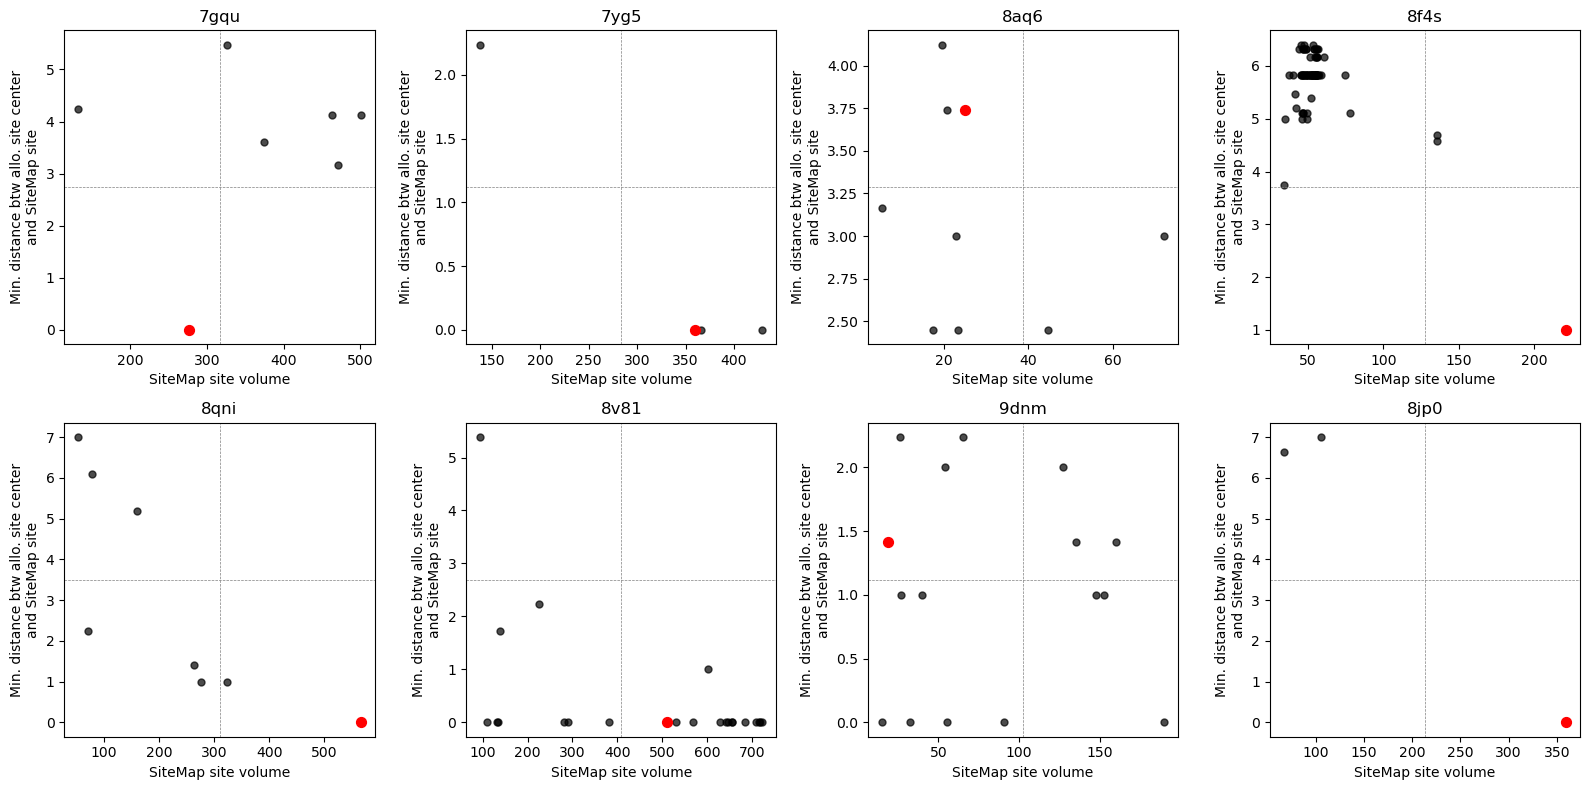

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pdbs = df["pdb"].unique()
n = len(pdbs)
cols = 4
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows), squeeze=False)

for ax, pdb in zip(axes.flatten(), pdbs):
    sub = df[df["pdb"] == pdb]

    # Scatter of all points
    ax.scatter(sub["volume"], sub["allositeCoG-SiteMap dist"],
               color="black", alpha=0.7, s=25)

    # Highlight the special point
    highlight = sub[sub["apo"] == pdb]
    if not highlight.empty:
        ax.scatter(highlight["volume"], highlight["allositeCoG-SiteMap dist"],
                   color="red", s=50, zorder=5)

    # Use the displayed axis ranges to find quadrant boundaries
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    
    xmid = (xmin + xmax) / 2
    ymid = (ymin + ymax) / 2
    
    # Draw quadrant lines
    ax.axvline(x=xmid, color="gray", linestyle="--", linewidth=0.5)
    ax.axhline(y=ymid, color="gray", linestyle="--", linewidth=0.5)

    ax.set_title(pdb)
    ax.set_xlabel("SiteMap site volume")
    ax.set_ylabel("Min. distance btw allo. site center\nand SiteMap site")

# Hide unused axes
for ax in axes.flatten()[n:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [26]:
import plotly.io as pio
pio.renderers.default = "notebook"

In [34]:
import pandas as pd
import plotly.express as px

# Boolean for highlight
df["apo_match"] = df["apo"] == df["pdb"]

fig = px.scatter(
    df,
    x="volume",
    y="allositeCoG-SiteMap dist",
    color="apo_match",               # True/False -> different colors
    hover_data=["pdb", "apo", "SiteMap", "volume", "allositeCoG-SiteMap dist"],
    facet_col="pdb",                 # one panel per PDB
    facet_col_wrap=4,                # wrap into rows of 4
    labels={
        "volume": "SiteMap volume",
        "allositeCoG-SiteMap dist": "Min. distance btw allo. site center and SiteMap site",
        "apo_match": "apo == pdb"
    },
)

# White background
fig.update_layout(
    plot_bgcolor="white",
    paper_bgcolor="white",
    legend_title_text="apo == pdb",
    height=800,
    width=1200,
)

# Unlink axes and remove gridlines, show tick labels
fig.for_each_xaxis(
    lambda a: a.update(
        matches=None,
        showgrid=False,        # <-- remove gridlines
        zeroline=False,
        linecolor="black",
        ticks="outside",
        showticklabels=True
    )
)
fig.for_each_yaxis(
    lambda a: a.update(
        matches=None,
        showgrid=False,        # <-- remove gridlines
        zeroline=False,
        linecolor="black",
        ticks="outside",
        showticklabels=True
    )
)

# Add vertical & horizontal threshold lines to every facet
fig.add_vline(x=200, line_width=1, line_dash="dash", line_color="gray")
fig.add_hline(y=4,   line_width=1, line_dash="dash", line_color="gray")

fig.show()

## Undetected

In [78]:
overlaps = {}

In [79]:
for holo, aposd in tqdm(apos.items()):
    # if holo != "8jp0":
    #     continue
    overlaps[holo] = {}
    
    holocif = Cif(holo, f"../training_data/7.Extra_set/cifs/{holo}.cif")
    holocif.residues = holocif.residues.replace({"pdbx_sifts_xref_db_acc": {"P32418-2": "P32418"}})
    u = holos_ups[holo]
    umin, umax = next(((min(us), max(us)) for us in (holocif.residues.query(f"pdbx_sifts_xref_db_acc == '{u}'")["pdbx_sifts_xref_db_num"].astype(int),)))
    
    realsite = extra_holos_sites[holo][0]["site"][["pdbx_sifts_xref_db_acc", "pdbx_sifts_xref_db_num"]].replace({"pdbx_sifts_xref_db_acc": {"P32418-2": "P32418"}}).query(f"pdbx_sifts_xref_db_acc == '{u}'")

    for apo, chain in tqdm(aposd.items(), desc=holo):
        # if apo in overlaps[holo] or 
        if apo in os.listdir("../training_data/8.Apos/Extra_set/features") or apo in ["7snx", "6wks", "8fzq"]:
            continue

        overlaps[holo][apo] = {}
            
        origciff = f"{extra_apos_original_cifs_path}/{apo}_updated.cif.gz"
        
        path = f"{extra_apos_path}/predictions/{apo}"
        if not os.path.isdir(path):
            os.makedirs(path, exist_ok=True)
            os.system(f"ln -s ../../origcifs/{apo}_updated.cif.gz {path}/")

        apocif = Cif(apo, origciff)
        seqmin, seqmax = (
            apocif.atoms
            .loc[lambda d: (
                d["pdbx_sifts_xref_db_acc"].eq(u) 
                & pd.to_numeric(d["pdbx_sifts_xref_db_num"], errors="coerce").between(umin, umax)
            )]
            .iloc[[0,-1]]["label_seq_id"].astype(int).to_list()
        )
        apocif.atoms = apocif.atoms.loc[lambda d: (
            pd.to_numeric(d["label_seq_id"], errors="coerce").between(seqmin, seqmax)
        )]

        if len(set(apocif.residues.pdbx_sifts_xref_db_acc.unique()) - {"?",} ) != 1:
            print(f"#### APO WITH MULTIPLE UNIPROTS: {apo}")

        clean_pdbf = f"{path}/{apo}.cif"
        if not os.path.isfile(clean_pdbf):
            clean_pdb = get_clean_pdb(apocif, chain, path)
        else:
            clean_pdb = Cif(apo, clean_pdbf)

        predsf = f"{path}/preds.pkl"
        if not os.path.isfile(predsf):
            continue
        
        preds = pd.read_pickle(predsf)

        for pocket in preds.index:
            site_in_apo = clean_pdb.residues.merge(realsite) # hopefully will preserve all columns of clean_pdb.residues
    
            pocketres = Pocket(f"{path}/{clean_pdb.entry_id}/{clean_pdb.entry_id}_out/pockets/{pocket}_atm.cif").residues
            merge = site_in_apo.merge(
                pocketres
            )
            
            overlaps[holo][apo][pocket] = {
                "pocket": pocket,
                "site_in_pocket": len(merge) / len(site_in_apo),
                "pocket_in_site": len(merge) / len(pocketres),
                "site": site_in_apo,
                "merge": merge
            }

# overlaps

  0%|          | 0/8 [00:00<?, ?it/s]

7gqu:   0%|          | 0/5 [00:00<?, ?it/s]

7yg5:   0%|          | 0/3 [00:00<?, ?it/s]

#### APO WITH MULTIPLE UNIPROTS: 8epm
#### APO WITH MULTIPLE UNIPROTS: 8epl


8aq6:   0%|          | 0/9 [00:00<?, ?it/s]

...

8v81:   0%|          | 0/19 [00:00<?, ?it/s]

#### APO WITH MULTIPLE UNIPROTS: 9dw8
#### APO WITH MULTIPLE UNIPROTS: 9dw7
#### APO WITH MULTIPLE UNIPROTS: 9dw5
#### APO WITH MULTIPLE UNIPROTS: 9dw4
#### APO WITH MULTIPLE UNIPROTS: 9dw9


9dnm:   0%|          | 0/15 [00:00<?, ?it/s]

#### APO WITH MULTIPLE UNIPROTS: 9cx9
#### APO WITH MULTIPLE UNIPROTS: 6u1n
#### APO WITH MULTIPLE UNIPROTS: 8ja3
#### APO WITH MULTIPLE UNIPROTS: 8j8z
#### APO WITH MULTIPLE UNIPROTS: 9bt8
#### APO WITH MULTIPLE UNIPROTS: 9cx3
#### APO WITH MULTIPLE UNIPROTS: 8gp3
#### APO WITH MULTIPLE UNIPROTS: 8i0q
#### APO WITH MULTIPLE UNIPROTS: 8i0n
#### APO WITH MULTIPLE UNIPROTS: 8go8


8jp0:   0%|          | 0/4 [00:00<?, ?it/s]

In [80]:
overlaps.keys(), overlaps["7gqu"]

(dict_keys(['7gqu', '7yg5', '8aq6', '8f4s', '8qni', '8v81', '9dnm', '8jp0']),
 {'7gqt': {'pocket5': {'pocket': 'pocket5',
    'site_in_pocket': 0.06896551724137931,
    'pocket_in_site': 0.16666666666666666,
    'site':    label_comp_id label_asym_id label_entity_id label_seq_id pdbx_PDB_ins_code  \
    0            VAL             A               1           55                 ?   
    1            MET             A               1           56                 ?   
    2            ALA             A               1           57                 ?   
    3            THR             A               1          188                 ?   
    4            ALA             A               1          189                 ?   
    5            THR             A               1          190                 ?   
    6            ALA             A               1          191                 ?   
    7            SER             A               1          192                 ?   
    8            AR

In [81]:
df = pd.DataFrame(
    [(pdb, apo, v['pocket'], v['site_in_pocket'], v['pocket_in_site'])
     for pdb, d1 in overlaps.items()
     for apo, d2 in d1.items()
     for v in d2.values()],
    columns=['pdb', 'apo', 'pocket', 'site_in_pocket', 'pocket_in_site']
)

df['label'] = (df['site_in_pocket'] >= 0.35).astype(int)
df['max_overlap'] = df[['site_in_pocket', 'pocket_in_site']].max(1)

print(len(df))
df.head()

2364


,pdb,apo,pocket,site_in_pocket,pocket_in_site,label,max_overlap
0,7gqu,7gqt,pocket5,0.068966,0.166667,0,0.166667
1,7gqu,7gqt,pocket1,0.310345,0.126761,0,0.310345
2,7gqu,7gqt,pocket4,0.206897,0.260870,0,0.260870
3,7gqu,7gqt,pocket10,0.172414,0.277778,0,0.277778
4,7gqu,7gqt,pocket9,0.310345,0.750000,0,0.750000


In [82]:
df.pdb.unique()

array(['7gqu', '7yg5', '8aq6', '8f4s', '8qni', '8v81', '9dnm', '8jp0'],
      dtype=object)

In [83]:
res = {}
for (pdb, apo), g in df.groupby(['pdb', 'apo']):
    if not g['label'].any():   # keep only apo with no pocket labeled 1
        res.setdefault(pdb, {})[apo] = (
            g.nlargest(3, 'max_overlap')['max_overlap'].tolist()
        )

res

{'7gqu': {'7gqs': [0.75, 0.47368421052631576, 0.35714285714285715],
  '7gqt': [0.75, 0.7142857142857143, 0.3103448275862069]},
 '8aq6': {'7snr': [0.3125, 0.1875, 0.125],
  '7sns': [0.38461538461538464, 0.06666666666666667, 0.0],
  '7snt': [0.07142857142857142, 0.07142857142857142],
  '7snw': [0.38461538461538464, 0.125, 0.09090909090909091],
  '7sny': [0.3333333333333333, 0.06666666666666667, 0.0],
  '8aqh': [0.2, 0.0625, 0.0]},
 '8f4s': {'6w4h': [0.7, 0.6153846153846154, 0.13636363636363635],
  '7bq7': [0.6666666666666666, 0.3333333333333333, 0.1],
  '7c2j': [0.6666666666666666, 0.4, 0.07142857142857142],
  '8osx': [0.6363636363636364, 0.5714285714285714, 0.3333333333333333],
  '8oto': [0.7, 0.47058823529411764, 0.36363636363636365],
  '8ov1': [0.7, 0.5, 0.15384615384615385],
  '8ov2': [0.6363636363636364, 0.4, 0.36363636363636365],
  '8rv6': [0.7, 0.47058823529411764, 0.09090909090909091],
  '8rv7': [0.7, 0.5333333333333333, 0.375],
  '8rv8': [0.7, 0.5333333333333333, 0.0952380952380

In [84]:
df.query("apo == '7gqs'").sort_values("max_overlap", ascending=False)

,pdb,apo,pocket,site_in_pocket,pocket_in_site,label,max_overlap
53,7gqu,7gqs,pocket6,0.310345,0.750000,0,0.750000
48,7gqu,7gqs,pocket21,0.310345,0.473684,0,0.473684
59,7gqu,7gqs,pocket11,0.172414,0.357143,0,0.357143
65,7gqu,7gqs,pocket20,0.068966,0.285714,0,0.285714
47,7gqu,7gqs,pocket1,0.275862,0.177778,0,0.275862
49,7gqu,7gqs,pocket5,0.172414,0.227273,0,0.227273
61,7gqu,7gqs,pocket16,0.068966,0.222222,0,0.222222
46,7gqu,7gqs,pocket4,0.068966,0.166667,0,0.166667
63,7gqu,7gqs,pocket14,0.034483,0.125000,0,0.125000
57,7gqu,7gqs,pocket9,0.034483,0.062500,0,0.062500


In [85]:
df.query("apo == '6w4h'").sort_values("max_overlap", ascending=False)

,pdb,apo,pocket,site_in_pocket,pocket_in_site,label,max_overlap
778,8f4s,6w4h,pocket9,0.269231,0.700000,0,0.700000
773,8f4s,6w4h,pocket2,0.307692,0.615385,0,0.615385
775,8f4s,6w4h,pocket7,0.115385,0.136364,0,0.136364
777,8f4s,6w4h,pocket1,0.038462,0.071429,0,0.071429
772,8f4s,6w4h,pocket3,0.000000,0.000000,0,0.000000
776,8f4s,6w4h,pocket5,0.000000,0.000000,0,0.000000
774,8f4s,6w4h,pocket8,0.000000,0.000000,0,0.000000
779,8f4s,6w4h,pocket4,0.000000,0.000000,0,0.000000
780,8f4s,6w4h,pocket6,0.000000,0.000000,0,0.000000


In [86]:
df.query("apo == '7snr'").sort_values("max_overlap", ascending=False)

,pdb,apo,pocket,site_in_pocket,pocket_in_site,label,max_overlap
185,8aq6,7snr,pocket3,0.3125,0.294118,0,0.3125
184,8aq6,7snr,pocket4,0.1875,0.166667,0,0.1875
183,8aq6,7snr,pocket1,0.1250,0.090909,0,0.1250
182,8aq6,7snr,pocket2,0.0000,0.000000,0,0.0000


In [87]:
overlaps["8aq6"]["7snr"]["pocket1"]["site"]

,label_comp_id,label_asym_id,label_entity_id,label_seq_id,pdbx_PDB_ins_code,auth_seq_id,auth_comp_id,auth_asym_id,pdbx_PDB_model_num,pdbx_label_index,pdbx_sifts_xref_db_name,pdbx_sifts_xref_db_acc,pdbx_sifts_xref_db_num,pdbx_sifts_xref_db_res
0,ASP,A,1,14,?,9,ASP,A,1,14,UNP,Q9GV45,36,D
1,TRP,A,1,15,?,10,TRP,A,1,15,UNP,Q9GV45,37,W
2,ARG,A,1,16,?,11,ARG,A,1,16,UNP,Q9GV45,38,Q
3,ILE,A,1,46,?,41,ILE,A,1,46,UNP,Q9GV45,68,I
4,ARG,A,1,48,?,43,ARG,A,1,48,UNP,Q9GV45,70,K
5,ASP,A,1,60,?,55,ASP,A,1,60,UNP,Q9GV45,82,D
6,HIS,A,1,62,?,57,HIS,A,1,62,UNP,Q9GV45,84,H
7,ILE,A,1,64,?,59,ILE,A,1,64,UNP,Q9GV45,86,I
8,TYR,A,1,86,?,81,TYR,A,1,86,UNP,Q9GV45,108,Y
9,PRO,A,1,87,?,82,PRO,A,1,87,UNP,Q9GV45,109,P


In [90]:
print(
    extra_holos_sites["8aq6"][0]["site"].auth_seq_id.astype(int).to_list()
)

[9, 10, 11, 41, 43, 55, 57, 59, 81, 82, 83, 88, 89, 91, 94, 167]


## Top2, 3

In [46]:
overlaps = {}

In [71]:
for holo, aposd in tqdm(apos.items()):
    # if holo != "8jp0":
    #     continue
    overlaps[holo] = {}
    
    holocif = Cif(holo, f"../training_data/7.Extra_set/cifs/{holo}.cif")
    holocif.residues = holocif.residues.replace({"pdbx_sifts_xref_db_acc": {"P32418-2": "P32418"}})
    u = holos_ups[holo]
    umin, umax = next(((min(us), max(us)) for us in (holocif.residues.query(f"pdbx_sifts_xref_db_acc == '{u}'")["pdbx_sifts_xref_db_num"].astype(int),)))
    
    realsite = extra_holos_sites[holo][0]["site"][["pdbx_sifts_xref_db_acc", "pdbx_sifts_xref_db_num"]].replace({"pdbx_sifts_xref_db_acc": {"P32418-2": "P32418"}}).query(f"pdbx_sifts_xref_db_acc == '{u}'")

    for apo, chain in tqdm(aposd.items(), desc=holo):
        # if apo in overlaps[holo] or 
        if apo in os.listdir("../training_data/8.Apos/Extra_set/features") or apo in ["7snx", "6wks", "8fzq"]:
            continue

        overlaps[holo][apo] = {}
            
        origciff = f"{extra_apos_original_cifs_path}/{apo}_updated.cif.gz"
        
        path = f"{extra_apos_path}/predictions/{apo}"
        if not os.path.isdir(path):
            os.makedirs(path, exist_ok=True)
            os.system(f"ln -s ../../origcifs/{apo}_updated.cif.gz {path}/")

        apocif = Cif(apo, origciff)
        seqmin, seqmax = (
            apocif.atoms
            .loc[lambda d: (
                d["pdbx_sifts_xref_db_acc"].eq(u) 
                & pd.to_numeric(d["pdbx_sifts_xref_db_num"], errors="coerce").between(umin, umax)
            )]
            .iloc[[0,-1]]["label_seq_id"].astype(int).to_list()
        )
        apocif.atoms = apocif.atoms.loc[lambda d: (
            pd.to_numeric(d["label_seq_id"], errors="coerce").between(seqmin, seqmax)
        )]

        if len(set(apocif.residues.pdbx_sifts_xref_db_acc.unique()) - {"?",} ) != 1:
            print(f"#### APO WITH MULTIPLE UNIPROTS: {apo}")

        clean_pdbf = f"{path}/{apo}.cif"
        if not os.path.isfile(clean_pdbf):
            clean_pdb = get_clean_pdb(apocif, chain, path)
        else:
            clean_pdb = Cif(apo, clean_pdbf)

        predsf = f"{path}/preds.pkl"
        if not os.path.isfile(predsf):
            continue
        
        preds = pd.read_pickle(predsf)

        for i, pocket in tuple(enumerate(preds.index, 1))[:3]:
            site_in_apo = clean_pdb.residues.merge(realsite) # hopefully will preserve all columns of clean_pdb.residues
    
            pocketres = Pocket(f"{path}/{clean_pdb.entry_id}/{clean_pdb.entry_id}_out/pockets/{pocket}_atm.cif").residues
            merge = site_in_apo.merge(
                pocketres
            )

            overlaps[holo][apo][pocket] = {
                "pocket": pocket,
                "top": i,
                "site_in_pocket": len(merge) / len(site_in_apo),
                "pocket_in_site": len(merge) / len(pocketres),
                "site": site_in_apo,
                "merge": merge
            }
            d = overlaps[holo][apo][pocket]
            d.update({
                "label": d["site_in_pocket"] >= 0.35# or d["pocket_in_site"] >= 0.7
            })

# overlaps

  0%|          | 0/8 [00:00<?, ?it/s]

7gqu:   0%|          | 0/5 [00:00<?, ?it/s]

7yg5:   0%|          | 0/3 [00:00<?, ?it/s]

#### APO WITH MULTIPLE UNIPROTS: 8epm
#### APO WITH MULTIPLE UNIPROTS: 8epl


8aq6:   0%|          | 0/9 [00:00<?, ?it/s]

...

8v81:   0%|          | 0/19 [00:00<?, ?it/s]

#### APO WITH MULTIPLE UNIPROTS: 9dw8
#### APO WITH MULTIPLE UNIPROTS: 9dw7
#### APO WITH MULTIPLE UNIPROTS: 9dw5
#### APO WITH MULTIPLE UNIPROTS: 9dw4
#### APO WITH MULTIPLE UNIPROTS: 9dw9


9dnm:   0%|          | 0/15 [00:00<?, ?it/s]

#### APO WITH MULTIPLE UNIPROTS: 9cx9
#### APO WITH MULTIPLE UNIPROTS: 6u1n
#### APO WITH MULTIPLE UNIPROTS: 8ja3
#### APO WITH MULTIPLE UNIPROTS: 8j8z
#### APO WITH MULTIPLE UNIPROTS: 9bt8
#### APO WITH MULTIPLE UNIPROTS: 9cx3
#### APO WITH MULTIPLE UNIPROTS: 8gp3
#### APO WITH MULTIPLE UNIPROTS: 8i0q
#### APO WITH MULTIPLE UNIPROTS: 8i0n
#### APO WITH MULTIPLE UNIPROTS: 8go8


8jp0:   0%|          | 0/4 [00:00<?, ?it/s]

In [72]:
overlaps.keys(), overlaps["7gqu"]

(dict_keys(['7gqu', '7yg5', '8aq6', '8f4s', '8qni', '8v81', '9dnm', '8jp0']),
 {'7gqt': {'pocket5': {'pocket': 'pocket5',
    'top': 1,
    'site_in_pocket': 0.06896551724137931,
    'pocket_in_site': 0.16666666666666666,
    'site':    label_comp_id label_asym_id label_entity_id label_seq_id pdbx_PDB_ins_code  \
    0            VAL             A               1           55                 ?   
    1            MET             A               1           56                 ?   
    2            ALA             A               1           57                 ?   
    3            THR             A               1          188                 ?   
    4            ALA             A               1          189                 ?   
    5            THR             A               1          190                 ?   
    6            ALA             A               1          191                 ?   
    7            SER             A               1          192                 ?   
    8

In [73]:
df = pd.DataFrame(
    [
        {"pdb": pdb, "apo": apo,
         "pocket": info.get("pocket"),
         "top": info.get("top"),
         "label": info.get("label")}
        for pdb, apo_dict in overlaps.items()
        for apo, pkts in apo_dict.items()
        for pkt, info in pkts.items()
    ]
)
df

,pdb,apo,pocket,top,label
0,7gqu,7gqt,pocket5,1,False
1,7gqu,7gqt,pocket1,2,False
2,7gqu,7gqt,pocket4,3,False
3,7gqu,8yle,pocket6,1,True
4,7gqu,8yle,pocket4,2,False
...,...,...,...,...,...
351,8jp0,8sgt,pocket18,2,False
352,8jp0,8sgt,pocket14,3,False
353,8jp0,8sgi,pocket2,1,True
354,8jp0,8sgi,pocket24,2,False


In [74]:
summary = df.groupby('pdb')['apo'].nunique().rename('total').to_frame()
summary

for X in [1, 2, 3]:
    # count rows with top <= X and label == True
    tps = df[(df['top'] <= X) & (df['label'])].groupby('pdb').size()
    summary[f'TPs in top {X}'] = tps.astype(int)
    summary[f'% top {X}'] = round(summary[f'TPs in top {X}'] / summary['total'] * 100, 2)

# replace NaNs (pdbs with no TPs) with 0
summary = summary.fillna(0).reset_index()

tp_cols = [col for col in summary.columns if col.startswith("TP")]
summary[tp_cols] = summary[tp_cols].astype(int)

summary

,pdb,total,TPs in top 1,% top 1,TPs in top 2,% top 2,TPs in top 3,% top 3
0,7gqu,4,2,50.00,2,50.00,2,50.00
1,7yg5,2,0,0.00,0,0.00,0,0.00
2,8aq6,7,0,0.00,1,14.29,1,14.29
3,8f4s,68,32,47.06,45,66.18,54,79.41
4,8jp0,3,3,100.00,3,100.00,3,100.00
5,8qni,4,3,75.00,4,100.00,4,100.00
6,8v81,17,2,11.76,4,23.53,8,47.06
7,9dnm,14,5,35.71,5,35.71,7,50.00


In [75]:
percent_cols = [col for col in summary.columns if col.startswith('% top')]

styled = (
    summary.style
    .background_gradient(subset=percent_cols, cmap="Greens")
    .format("{:.2f}", subset=percent_cols)  # keep 2 decimals
)

styled

,pdb,total,TPs in top 1,% top 1,TPs in top 2,% top 2,TPs in top 3,% top 3
0,7gqu,4,2,50.00,2,50.00,2,50.00
1,7yg5,2,0,0.00,0,0.00,0,0.00
2,8aq6,7,0,0.00,1,14.29,1,14.29
3,8f4s,68,32,47.06,45,66.18,54,79.41
4,8jp0,3,3,100.00,3,100.00,3,100.00
5,8qni,4,3,75.00,4,100.00,4,100.00
6,8v81,17,2,11.76,4,23.53,8,47.06
7,9dnm,14,5,35.71,5,35.71,7,50.00


In [77]:
extra_holos_sites["8aq6"][0]["site"]

,label_comp_id,label_asym_id,label_entity_id,label_seq_id,pdbx_PDB_ins_code,auth_seq_id,auth_comp_id,auth_asym_id,pdbx_PDB_model_num,pdbx_label_index,pdbx_sifts_xref_db_name,pdbx_sifts_xref_db_acc,pdbx_sifts_xref_db_num,pdbx_sifts_xref_db_res
0,ASP,G,1,21,?,9,ASP,G,1,21,UNP,Q9GV45,36,D
1,TRP,G,1,22,?,10,TRP,G,1,22,UNP,Q9GV45,37,W
2,ARG,G,1,23,?,11,ARG,G,1,23,UNP,Q9GV45,38,Q
3,ILE,G,1,53,?,41,ILE,G,1,53,UNP,Q9GV45,68,I
4,ARG,G,1,55,?,43,ARG,G,1,55,UNP,Q9GV45,70,K
5,ASP,G,1,67,?,55,ASP,G,1,67,UNP,Q9GV45,82,D
6,HIS,G,1,69,?,57,HIS,G,1,69,UNP,Q9GV45,84,H
7,ILE,G,1,71,?,59,ILE,G,1,71,UNP,Q9GV45,86,I
8,TYR,G,1,93,?,81,TYR,G,1,93,UNP,Q9GV45,108,Y
9,PRO,G,1,94,?,82,PRO,G,1,94,UNP,Q9GV45,109,P


## Overlaps

In [39]:
overlapsf = f"{extra_apos_path}/predictions.pkl"

In [40]:
if os.path.isfile(overlapsf):
    overlaps = pd.read_pickle(overlapsf)
else:
    overlaps = {}

In [41]:
overlaps.keys(), overlaps["7gqu"]

(dict_keys(['7gqu', '7yg5', '8aq6', '8f4s', '8qni', '8v81', '9dnm', '8jp0']),
 {'7gqt': {'pocket': 'pocket5',
   'site_in_pocket': 0.06896551724137931,
   'pocket_in_site': 0.16666666666666666,
   'site':    label_comp_id label_asym_id label_entity_id label_seq_id pdbx_PDB_ins_code  \
   0            VAL             A               1           55                 ?   
   1            MET             A               1           56                 ?   
   2            ALA             A               1           57                 ?   
   3            THR             A               1          188                 ?   
   4            ALA             A               1          189                 ?   
   5            THR             A               1          190                 ?   
   6            ALA             A               1          191                 ?   
   7            SER             A               1          192                 ?   
   8            ARG             A         

In [ ]:
overlaps_bu = overlaps

In [ ]:
overlaps = {}

In [ ]:
for holo, aposd in tqdm(apos.items()):
    # if holo != "8jp0":
    #     continue
    overlaps[holo] = {}
    
    holocif = Cif(holo, f"../training_data/7.Extra_set/cifs/{holo}.cif")
    holocif.residues = holocif.residues.replace({"pdbx_sifts_xref_db_acc": {"P32418-2": "P32418"}})
    u = holos_ups[holo]
    umin, umax = next(((min(us), max(us)) for us in (holocif.residues.query(f"pdbx_sifts_xref_db_acc == '{u}'")["pdbx_sifts_xref_db_num"].astype(int),)))
    
    realsite = extra_holos_sites[holo][0]["site"][["pdbx_sifts_xref_db_acc", "pdbx_sifts_xref_db_num"]].replace({"pdbx_sifts_xref_db_acc": {"P32418-2": "P32418"}}).query(f"pdbx_sifts_xref_db_acc == '{u}'")

    for apo, chain in tqdm(aposd.items(), desc=holo):
        if apo in overlaps[holo] or apo in os.listdir("../training_data/8.Apos/Extra_set/features") or apo in ["7snx", "6wks", "8fzq"]:
            continue
            
        origciff = f"{extra_apos_original_cifs_path}/{apo}_updated.cif.gz"
        
        path = f"{extra_apos_path}/predictions/{apo}"
        os.makedirs(path, exist_ok=True)
        os.system(f"ln -s ../../origcifs/{apo}_updated.cif.gz {path}/")

        apocif = Cif(apo, origciff)
        seqmin, seqmax = (
            apocif.atoms
            .loc[lambda d: (
                d["pdbx_sifts_xref_db_acc"].eq(u) 
                & pd.to_numeric(d["pdbx_sifts_xref_db_num"], errors="coerce").between(umin, umax)
            )]
            .iloc[[0,-1]]["label_seq_id"].astype(int).to_list()
        )
        apocif.atoms = apocif.atoms.loc[lambda d: (
            pd.to_numeric(d["label_seq_id"], errors="coerce").between(seqmin, seqmax)
        )]

        if len(set(apocif.residues.pdbx_sifts_xref_db_acc.unique()) - {"?",} ) != 1:
            print(f"#### APO WITH MULTIPLE UNIPROTS: {apo}")
        clean_pdb = get_clean_pdb(apocif, chain, path)

        predsf = f"{path}/preds.pkl"
        if not os.path.isfile(predsf):
            pockets = get_pockets(
                clean_pdb,
                out=sys.stdout,
                path=path
            )
            pockets["pdb"] = clean_pdb.entry_id
        
            for feat in ['features', 'transferentropy', 'hhblits']:
                subprocess.run(f"python ../gradio/{feat}.py {clean_pdb.entry_id} {path}", shell=True, check=True)
        
            features = get_pdb_features(
                clean_pdb,
                sites = [pd.DataFrame(columns=clean_pdb.residues.columns),],
                features_path = path
            )
        
            pockets_features = get_pockets_features(
                clean_pdb,
                pockets,
                features,
                path=path
            )
        
            data = prepare_data(pockets_features)
        
            preds = model.predict_proba(data)[[1]].sort_values(1, ascending=False).rename(columns={1: "Allosteric score"})
            preds.index = preds.index.map(lambda x: x.split("_")[-1])
            
            preds.to_pickle(predsf)
        else:
            preds = pd.read_pickle(predsf)

        topp = preds.iloc[0].name
        
        site_in_apo = clean_pdb.residues.merge(realsite) # hopefully will preserve all columns of clean_pdb.residues

        pocketres = Pocket(f"{path}/{clean_pdb.entry_id}/{clean_pdb.entry_id}_out/pockets/{topp}_atm.cif").residues
        merge = site_in_apo.merge(
            pocketres
        )
        
        overlaps[holo][apo] = {
            "pocket": topp,
            "site_in_pocket": len(merge) / len(site_in_apo),
            "pocket_in_site": len(merge) / len(pocketres),
            "site": site_in_apo,
            "merge": merge
        }

        pd.to_pickle(overlaps, overlapsf)

In [42]:
df = pd.DataFrame([
    dict(
        **{"holo": holo, "apo": apo},
        **apod
    )
    for holo, holod in overlaps.items()
    for apo, apod in holod.items()
]).drop(columns=["site", "merge"])

In [43]:
df

,holo,apo,pocket,site_in_pocket,pocket_in_site
0,7gqu,7gqt,pocket5,0.068966,0.166667
1,7gqu,8yle,pocket6,0.448276,0.464286
2,7gqu,8pfp,pocket1,0.586207,0.269841
3,7gqu,7gqs,pocket4,0.068966,0.166667
4,7yg5,8epm,pocket1,0.000000,0.000000
...,...,...,...,...,...
114,9dnm,8i0n,pocket2,0.000000,0.000000
115,9dnm,8go8,pocket20,0.300000,0.076923
116,8jp0,9iv8,pocket1,0.562500,0.197802
117,8jp0,8sgt,pocket17,0.516129,0.380952


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

ax = sns.scatterplot(data=df, x="site_in_pocket", y="pocket_in_site", hue="holo", s=50, alpha=.85, legend="full", palette = sns.color_palette("colorblind", n_colors=9))
ax.set(xlim=(0,1), ylim=(0,1), xticks=[0,.25,.5,.75,1], yticks=[0,.25,.5,.75,1],
       xlabel="Fraction of site in pocket", ylabel="Fraction of pocket in site",
       title="Pocket vs Site by holo")
plt.axvline(.5, ls="--", lw=1); plt.axhline(.5, ls="--", lw=1)
plt.legend(title="holo", bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout(); plt.show()

In [43]:
df.loc[lambda x: x["holo"] == "9dnm"]

,holo,apo,pocket,site_in_pocket,pocket_in_site
102,9dnm,9cx9,pocket11,0.000000,0.000000
105,9dnm,8hst,pocket5,0.000000,0.000000
107,9dnm,6kl7,pocket4,0.000000,0.000000
108,9dnm,8j8z,pocket5,0.000000,0.000000
109,9dnm,9bt8,pocket9,0.000000,0.000000
110,9dnm,9cx3,pocket15,0.000000,0.000000
114,9dnm,8i0n,pocket2,0.000000,0.000000
111,9dnm,8hsv,pocket7,0.200000,0.055556
115,9dnm,8go8,pocket20,0.300000,0.076923
103,9dnm,9dng,pocket1,0.400000,0.045977


In [ ]:
# Ridgeline-like plot per user spec (pure matplotlib, custom KDE, colored per holo)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# You can switch which value column to plot here:
value_col = "site_in_pocket"  # or "pocket_in_site"

# ---- Utility: simple Gaussian KDE (numpy only) ----
def gaussian_kde_numpy(samples, x_grid, bw=None):
    samples = np.asarray(samples, dtype=float)
    if samples.size == 0:
        return np.zeros_like(x_grid, dtype=float)
    if bw is None:
        # Silverman's rule of thumb; fall back if std ~ 0
        std = samples.std(ddof=1) if samples.size > 1 else 0.0
        bw = 1.06 * (std if std > 1e-8 else 0.05) * (samples.size ** (-1/5))
        if bw < 1e-3:
            bw = 1e-3
    diff = (x_grid[:, None] - samples[None, :]) / bw
    # standard normal pdf
    dens = np.exp(-0.5 * diff**2) / np.sqrt(2 * np.pi)
    kde = dens.mean(axis=1) / bw
    return kde

# ---- Prepare data ----
holos = sorted(df["holo"].unique())
n_holos = len(holos)

# We’ll assume values are between 0 and 1 (as in your data)
global_min, global_max = 0.0, 1.0
x_pad_left, x_pad_right = 0.05, 0.05  # leave extra room for left/right labels
x = np.linspace(global_min, global_max, 400)

# ---- Figure ----
dpi = 140
fig_height = max(2.2, 1.0 + 0.7 * n_holos)
fig, ax = plt.subplots(figsize=(6, fig_height), dpi=dpi, constrained_layout=True)

# Visual constants
row_gap = 1.0           # distance between baselines
amp = 0.75              # max curve height within each row (keep KDE within row)
baseline_offset = 0.5   # baseline at exact row y
# point_offset = 0.08     # datapoints slightly above baseline so they are visible
lw_curve = 1.6
lw_base = 0.9
ms_points = 15

# Colorblind-friendly diverging palette (9 colors max)
palette = sns.color_palette("colorblind", n_colors=9)
colors = {h: palette[i % len(palette)] for i, h in enumerate(holos)}

# ---- Plot each row ----
for i, holo in enumerate(holos):
    subset = df.loc[df["holo"] == holo, value_col].astype(float).values
    y0 = (n_holos - 1 - i) * row_gap  # top-to-bottom ordering
    
    # KDE line (scaled to fit within row height)
    kde = gaussian_kde_numpy(subset, x)
    if np.allclose(kde.max(), 0):
        kde_scaled = np.zeros_like(kde)
    else:
        kde_scaled = (kde / kde.max()) * amp
    
    ax.plot(x, y0 + kde_scaled, linewidth=lw_curve, color=colors[holo], zorder=3, alpha=0.5)
    
    # Thin, light gray, straight horizontal baseline
    ax.hlines(y0, global_min, global_max, color="#C8C8C8", linewidth=lw_base, zorder=1) # y0 + baseline_offset
    
    # Datapoints as small circles slightly above the baseline
    if subset.size > 0:
        # Horizontal jitter (e.g., ±0.01)
        # jitter_x = np.random.uniform(-0.01, 0.01, size=subset.size)
        # Vertical jitter around the baseline offset + point_offset
        jitter_y = np.random.uniform(-0.075, 0.075, size=subset.size)
    
        ax.scatter(
            subset,# + jitter_x,
            np.full_like(subset, y0 + baseline_offset ) + jitter_y, # + point_offset
            s=ms_points,
            facecolor=colors[holo],
            edgecolor="none",
            alpha=0.6,
            zorder=4
        )
    
    # Labels: holo on the left (unrotated), n= on the right
    ax.text(global_min - x_pad_left, y0 + baseline_offset, f"{holo}",
            ha="right", va="center", fontsize=10)
    ax.text(global_max + x_pad_right, y0 + baseline_offset, f"n={subset.size}",
            ha="left", va="center", fontsize=10)

# ---- Aesthetics ----
# Axis limits leave room for labels
ax.set_xlim(global_min - x_pad_left, global_max + x_pad_right)
ax.set_ylim(-0.5, (n_holos - 1) * row_gap + amp + 0.5)

# Remove y-axis, ticks, and legend; keep a clean x-axis
ax.spines["left"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.set_yticks([])

# Light x-axis with subtle ticks
ax.spines["bottom"].set_linewidth(0.8)
ax.tick_params(axis="x", which="both", length=3, width=0.8, labelsize=9)
ax.set_xlabel("% of allosteric site residues in top pocket", labelpad=8)
ax.set_xlim(-0.02, 1.02)
# ax.set_xmargin(0.1)

ax.set_title("AlloPockets on PDB ensembles")
# No legend or titles
# (not creating a legend; title intentionally omitted)

plt.show()


## Results

- For **7gqu** all 4 structures have an acceptable pocket. 8pfp's pocket includes the allo site but is very big, and 7gqt/7gqs are small pockets within the allo site. They all have a bound ligand in a different site and AlloPockets is successful at discriminating.
- For **7yg5** the results are still incorrect and moreover they are not consistent.
- For **8aq6**, the results are mostly negative as with the originally-chosen apo, predicting the orthosteric site. For 7vsx and 7sny the predicted pocket extends a bit through the surface.
- For 8f4s (so far), predictions are consistent with the originally-chosen apo; but the pocket is the one that contains the ortho ligand and extends a bit (~35% of residues) to the allosteric site.
- For **8v81**, pockets are wrongly predicted and the only two with high overlap are enormous pockets spanning the whole structure.
- For 9dnm, results aren't great either and the ones showing overlap are again big pockets and mostly do not cover the surface-shallow site, but come from behind or from the side. The pockets would also need to be compared with the non-annotated pocket.
- For **8qni** the results are good, with 3/4 apos (+ original apo) being correct predictions.
- For **8jp0**, the results are also good, although in one of the 2 apos (+ original apo) the predicted pocket is very big.

In [31]:
apos = pd.read_pickle(aposf)
apos["8jp0"].pop("8sgi")
dict(sorted({k: len(v) for k, v in apos.items()}.items(), key=lambda x: x[1], reverse=True))

{'8f4s': 70,
 '8v81': 19,
 '9dnm': 15,
 '8aq6': 9,
 '7gqu': 5,
 '8qni': 5,
 '7yg5': 3,
 '8jp0': 3}

In [32]:
overlaps = pd.read_pickle(overlapsf)
# 8sgi is not apo
overlaps["8jp0"].pop("8sgi")
dict(sorted({k: len(v) for k, v in overlaps.items()}.items(), key=lambda x: x[1], reverse=True))

{'8f4s': 68,
 '8v81': 17,
 '9dnm': 14,
 '8aq6': 7,
 '7gqu': 4,
 '8qni': 4,
 '7yg5': 2,
 '8jp0': 2}

**8v81**
- 6o1v: top4 18%
- 7svd: -
- 7sv7: top3 8%
- 8eig: top3 27%
- 6msm: top5 24%
- 9dw9: top5 8%
- 9dw5: top6 27%
- 8v7z: top3 16%
- 8eio: top5 7%
- 8gls: top4 25%
- 7svr: top2 23%
- 9dw8: top2 54%
- 8eiq: top4 40%
- 6o2p: top5 19%
- 9dw7: top3 63%
- 9dw4, 8ej1

**7yg5**
- 8epm:
    - top1: could coincide with modulator in 8F0Q (chimera Na channel) when taking account symmetry
    - top2: -
    - top3: -
    - top4: pore
    - top5: -
- 8epl:
    - top1: -
    - top2: -, similar to top3 from 8epm
    - top3: -, similar to top2 from 8epm
    - top4: coincides with modulator in 8QUD

In [35]:
holo = "8jp0"
pd.DataFrame(overlaps[holo]).T.sort_values("overlap")

,pocket,overlap,site,merge
8sgt,pocket17,0.516129,label_comp_id label_asym_id label_entity_id label_seq_id pdbx_PDB_ins_code \ 0 GLU A 1 132 ? 1 THR A 1 133 ? 2 VAL A 1 134 ? 3 SER A 1 135 ? 4 LEU A 1 137 ? 5 THR A 1 138 ? 6 ALA ...,label_comp_id label_asym_id label_entity_id label_seq_id pdbx_PDB_ins_code \ 0 GLU A 1 132 ? 1 THR A 1 133 ? 2 VAL A 1 134 ? 3 LEU A 1 137 ? 4 THR A 1 138 ? 5 ALA A 1 141 ? 6 HIS ...
8sgi,pocket2,0.53125,label_comp_id label_asym_id label_entity_id label_seq_id pdbx_PDB_ins_code \ 0 GLU A 1 132 ? 1 THR A 1 133 ? 2 VAL A 1 134 ? 3 SER A 1 135 ? 4 LEU A 1 137 ? 5 THR A 1 138 ? 6 ALA ...,label_comp_id label_asym_id label_entity_id label_seq_id pdbx_PDB_ins_code \ 0 GLU A 1 132 ? 1 THR A 1 133 ? 2 VAL A 1 134 ? 3 LEU A 1 137 ? 4 THR A 1 138 ? 5 ALA A 1 141 ? 6 HIS ...
9iv8,pocket1,0.5625,label_comp_id label_asym_id label_entity_id label_seq_id pdbx_PDB_ins_code \ 0 GLU A 1 132 ? 1 THR A 1 133 ? 2 VAL A 1 134 ? 3 SER A 1 135 ? 4 LEU A 1 137 ? 5 THR A 1 138 ? 6 ALA ...,label_comp_id label_asym_id label_entity_id label_seq_id pdbx_PDB_ins_code \ 0 GLU A 1 132 ? 1 THR A 1 133 ? 2 VAL A 1 134 ? 3 SER A 1 135 ? 4 LEU A 1 137 ? 5 THR A 1 138 ? 6 ALA ...


In [41]:
pdb = "9iv8"
toppocket = 1

preds = pd.read_pickle(f"pdb_ensemble/predictions/{pdb}/preds.pkl").iloc[:5]; print(preds)
cif = Cif(pdb, f'pdb_ensemble/predictions/{pdb}/{pdb}.cif')
view_pockets(
    cif,
    pockets={preds.iloc[toppocket-1].name: {"color": "green"}},
    site_residues=cif.residues.merge(
        extra_holos_sites[holo][0]["site"][["pdbx_sifts_xref_db_acc", "pdbx_sifts_xref_db_num"]].replace({"pdbx_sifts_xref_db_acc": {"P32418-2": "P32418"}})
    ),
    path=f'pdb_ensemble/predictions/{pdb}',
)

          Allosteric score
pocket1           0.980263
pocket25          0.004346
pocket17          0.003290
pocket3           0.003146
pocket23          0.002185


PDBeMolstar(bg_color='#F7F7F7', color_data={'data': [{'struct_asym_id': 'A', 'representation': 'cartoon', 'rep…

# Consensus

In [35]:
origapos = pd.read_pickle("../models/other_tools_apos/models_lenient_labelling.pkl")["model5"]
origapos.keys(), origapos["results"]["4jqi"]

{'results': {'4jqi': {'pocket16': {'prob': 0.0001226096646860242,
    'pred': 0,
    'label': 0,
    'max_overlap': 0.0,
    'pocket_in_site': 0.0,
    'site_in_pocket': 0.0},
   'pocket18': {'prob': 0.003527346532791853,
    'pred': 0,
    'label': 0,
    'max_overlap': 0.0,
    'pocket_in_site': 0.0,
    'site_in_pocket': 0.0},
   'pocket11': {'prob': 4.818243542104028e-05,
    'pred': 0,
    'label': 0,
    'max_overlap': 0.0,
    'pocket_in_site': 0.0,
    'site_in_pocket': 0.0},
   'pocket15': {'prob': 1.1008408629109567e-09,
    'pred': 0,
    'label': 0,
    'max_overlap': 0.0,
    'pocket_in_site': 0.0,
    'site_in_pocket': 0.0},
   'pocket7': {'prob': 0.0006957116420380771,
    'pred': 0,
    'label': 0,
    'max_overlap': 0.0,
    'pocket_in_site': 0.0,
    'site_in_pocket': 0.0},
   'pocket13': {'prob': 0.09678139537572861,
    'pred': 0,
    'label': 0,
    'max_overlap': 0.0,
    'pocket_in_site': 0.0,
    'site_in_pocket': 0.0},
   'pocket14': {'prob': 1.2360335688299529

## Tests

In [56]:
origapos.keys()

dict_keys(['results', 'all_pockets_in_output', 'prob_key', 'labelling'])

In [46]:
holo = "8jp0"

In [47]:
apos[holo]

{'8sgj': 'A', '9iv8': 'A', '8sgt': 'A'}

In [48]:
overlaps[holo]

{'9iv8': {'pocket': 'pocket1',
  'overlap': 0.5625,
  'site':    label_comp_id label_asym_id label_entity_id label_seq_id pdbx_PDB_ins_code  \
  0            GLU             A               1          132                 ?   
  1            THR             A               1          133                 ?   
  2            VAL             A               1          134                 ?   
  3            SER             A               1          135                 ?   
  4            LEU             A               1          137                 ?   
  5            THR             A               1          138                 ?   
  6            ALA             A               1          141                 ?   
  7            HIS             A               1          200                 ?   
  8            VAL             A               1          203                 ?   
  9            VAL             A               1          206                 ?   
  10           THR         

In [52]:
refapo = next(apo for apo in apos[holo] if apo in os.listdir("../training_data/8.Apos/Extra_set/features"))
refapo

'8sgj'

In [61]:
refaporesults = pd.DataFrame( origapos["results"][refapo] ).T.sort_values("prob", ascending=False)
refaporesults

,prob,pred,label,max_overlap,pocket_in_site,site_in_pocket
pocket1,0.981097,1.0,0.0,0.531250,0.188889,0.53125
pocket23,0.315970,0.0,0.0,0.000000,0.000000,0.00000
pocket2,0.059493,0.0,0.0,0.031250,0.024390,0.03125
pocket10,0.017046,0.0,0.0,0.000000,0.000000,0.00000
pocket26,0.003989,0.0,0.0,0.000000,0.000000,0.00000
pocket6,0.002535,0.0,0.0,0.187500,0.176471,0.18750
pocket17,0.002097,0.0,0.0,0.000000,0.000000,0.00000
pocket22,0.001774,0.0,0.0,0.000000,0.000000,0.00000
pocket11,0.001373,0.0,0.0,0.000000,0.000000,0.00000
pocket19,0.001282,0.0,0.0,0.000000,0.000000,0.00000


In [68]:
refapocif = Cif(refapo, f"../training_data/8.Apos/Extra_set/cifs/{refapo}.cif")
refapocif.residues

,label_comp_id,label_asym_id,label_entity_id,label_seq_id,pdbx_PDB_ins_code,auth_seq_id,auth_comp_id,auth_asym_id,pdbx_PDB_model_num,pdbx_label_index,pdbx_sifts_xref_db_name,pdbx_sifts_xref_db_acc,pdbx_sifts_xref_db_num,pdbx_sifts_xref_db_res
0,SER,A,1,52,?,17,SER,A,1,52,UNP,P32418,52,S
6,TYR,A,1,53,?,18,TYR,A,1,53,UNP,P32418,53,Y
18,TYR,A,1,54,?,19,TYR,A,1,54,UNP,P32418,54,Y
30,CYS,A,1,55,?,20,CYS,A,1,55,UNP,P32418,55,C
36,LYS,A,1,56,?,21,LYS,A,1,56,UNP,P32418,56,K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5864,ALA,A,1,941,?,931,ALA,A,1,941,UNP,P32418,966,A
5869,TYR,A,1,942,?,932,TYR,A,1,942,UNP,P32418,967,Y
5881,CYS,A,1,943,?,933,CYS,A,1,943,UNP,P32418,968,C
5887,HIS,A,1,944,?,934,HIS,A,1,944,UNP,P32418,969,H


In [69]:
refapopred = refapocif.residues.merge(
    Pocket(f"../training_data/8.Apos/Extra_set/pockets/{refapo}/{refapo}_out/pockets/{refaporesults.iloc[0].name}_atm.cif").residues
)
refapopred

,label_comp_id,label_asym_id,label_entity_id,label_seq_id,pdbx_PDB_ins_code,auth_seq_id,auth_comp_id,auth_asym_id,pdbx_PDB_model_num,pdbx_label_index,pdbx_sifts_xref_db_name,pdbx_sifts_xref_db_acc,pdbx_sifts_xref_db_num,pdbx_sifts_xref_db_res
0,LEU,A,1,90,?,55,LEU,A,1,90,UNP,P32418,90,L
1,SER,A,1,93,?,58,SER,A,1,93,UNP,P32418,93,S
2,ILE,A,1,94,?,59,ILE,A,1,94,UNP,P32418,94,I
3,ASP,A,1,97,?,62,ASP,A,1,97,UNP,P32418,97,D
4,ARG,A,1,98,?,63,ARG,A,1,98,UNP,P32418,98,R
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,ASN,A,1,844,?,834,ASN,A,1,844,UNP,P32418,869,N
86,THR,A,1,846,?,836,THR,A,1,846,UNP,P32418,871,T
87,GLY,A,1,847,?,837,GLY,A,1,847,UNP,P32418,872,G
88,ALA,A,1,850,?,840,ALA,A,1,850,UNP,P32418,875,A


In [74]:
aposres = [ refapopred[["pdbx_sifts_xref_db_acc", "pdbx_sifts_xref_db_num"]], ]
for apo, apod in overlaps[holo].items():
    aposres.append(
        Cif(apo, f"pdb_ensemble/predictions/{apo}/{apo}.cif").residues
        .merge(
            Pocket(f"pdb_ensemble/predictions/{apo}/{apo}/{apo}_out/pockets/{apod['pocket']}_atm.cif").residues
        )[
            ["pdbx_sifts_xref_db_acc", "pdbx_sifts_xref_db_num"]
        ]
    )
aposres

[   pdbx_sifts_xref_db_acc pdbx_sifts_xref_db_num
 0                  P32418                     90
 1                  P32418                     93
 2                  P32418                     94
 3                  P32418                     97
 4                  P32418                     98
 ..                    ...                    ...
 85                 P32418                    869
 86                 P32418                    871
 87                 P32418                    872
 88                 P32418                    875
 89                 P32418                    876
 
 [90 rows x 2 columns],
    pdbx_sifts_xref_db_acc pdbx_sifts_xref_db_num
 0                  P32418                     93
 1                  P32418                     94
 2                  P32418                     97
 3                  P32418                     98
 4                  P32418                    100
 ..                    ...                    ...
 86                 P324

In [ ]:
pdb = "9iv8"
toppocket = 1

preds = pd.read_pickle(f"pdb_ensemble/predictions/{pdb}/preds.pkl").iloc[:5]; print(preds)
cif = Cif(pdb, f'pdb_ensemble/predictions/{pdb}/{pdb}.cif')
view_pockets(
    refapocif,
    pockets={preds.iloc[toppocket-1].name: {"color": "green"}},
    site_residues=cif.residues.merge(
        extra_holos_sites[holo][0]["site"][["pdbx_sifts_xref_db_acc", "pdbx_sifts_xref_db_num"]].replace({"pdbx_sifts_xref_db_acc": {"P32418-2": "P32418"}})
    ),
    path=f'pdb_ensemble/predictions/{pdb}',
)

### MVS

In [105]:
import molviewspec as mvs
import json

In [129]:
builder = mvs.create_builder()
structure = (
    builder
    .download(url="cif")
    .parse(format="mmcif")
    .model_structure()
)
assets = {'cif': refapocif.cif.text.encode()}

In [130]:
proteins = (
    structure
    .component(selector=[
        mvs.ComponentExpression(**{"label_asym_id": c})
        for c in refapocif.residues.label_asym_id.unique()
    ])
    .focus()
    .representation(type="cartoon")
    .color(color='#FFFFFF')
)
# (
#     structure
#     .component(selector=[
#         mvs.ComponentExpression(**{"label_asym_id": c})
#         for c in all_chains
#         if c not in chain
#     ])
#     .representation(type="cartoon")
#     .color(color='white')
#     .opacity(opacity=0.5)
# )
# (
#     structure
#     .component(selector="ligand")
#     .representation()
#     .color(
#         custom={
#             "molstar_color_theme_name": "element-symbol",
#             "molstar_color_theme_params": {
#                 "carbonColor": { "name": "uniform", "params": {"value": int("#808080".replace('#', ''), 16)} }
#             }
#         }
#     )
# )
# (
#     structure
#     .component(selector="ion")
#     .representation()
#     .color(custom={"molstar_color_theme_name": "element-symbol"})
# )

In [131]:
import pandas as pd
import numpy as np
from matplotlib.colors import to_hex

In [132]:
aposres

[   pdbx_sifts_xref_db_acc pdbx_sifts_xref_db_num
 0                  P32418                     90
 1                  P32418                     93
 2                  P32418                     94
 3                  P32418                     97
 4                  P32418                     98
 ..                    ...                    ...
 85                 P32418                    869
 86                 P32418                    871
 87                 P32418                    872
 88                 P32418                    875
 89                 P32418                    876
 
 [90 rows x 2 columns],
    pdbx_sifts_xref_db_acc pdbx_sifts_xref_db_num
 0                  P32418                     93
 1                  P32418                     94
 2                  P32418                     97
 3                  P32418                     98
 4                  P32418                    100
 ..                    ...                    ...
 86                 P324

In [133]:
colors = pd.concat(aposres).value_counts().to_frame().reset_index()
colors

,pdbx_sifts_xref_db_acc,pdbx_sifts_xref_db_num,count
0,P32418,137,3
1,P32418,134,3
2,P32418,100,3
3,P32418,865,3
4,P32418,876,3
...,...,...,...
109,P32418,246,1
110,P32418,251,1
111,P32418,202,1
112,P32418,139,1


In [134]:
colors["count"].max()

3

In [135]:
steps = np.linspace(128, 0, colors["count"].max()).round().astype(int)
steps

array([128,  64,   0])

In [136]:
palette = [to_hex((v / 255, v / 255, v / 255)) for v in steps]
palette

['#808080', '#404040', '#000000']

In [137]:
colors["color"] = colors["count"].map(lambda k: palette[int(k) - 1])
colors

,pdbx_sifts_xref_db_acc,pdbx_sifts_xref_db_num,count,color
0,P32418,137,3,#000000
1,P32418,134,3,#000000
2,P32418,100,3,#000000
3,P32418,865,3,#000000
4,P32418,876,3,#000000
...,...,...,...,...
109,P32418,246,1,#808080
110,P32418,251,1,#808080
111,P32418,202,1,#808080
112,P32418,139,1,#808080


In [138]:
refapocif.residues.merge(
    colors
)

,label_comp_id,label_asym_id,label_entity_id,label_seq_id,pdbx_PDB_ins_code,auth_seq_id,auth_comp_id,auth_asym_id,pdbx_PDB_model_num,pdbx_label_index,pdbx_sifts_xref_db_name,pdbx_sifts_xref_db_acc,pdbx_sifts_xref_db_num,pdbx_sifts_xref_db_res,count,color
0,LEU,A,1,90,?,55,LEU,A,1,90,UNP,P32418,90,L,1,#808080
1,SER,A,1,93,?,58,SER,A,1,93,UNP,P32418,93,S,2,#404040
2,ILE,A,1,94,?,59,ILE,A,1,94,UNP,P32418,94,I,2,#404040
3,ASP,A,1,97,?,62,ASP,A,1,97,UNP,P32418,97,D,2,#404040
4,ARG,A,1,98,?,63,ARG,A,1,98,UNP,P32418,98,R,2,#404040
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109,GLY,A,1,847,?,837,GLY,A,1,847,UNP,P32418,872,G,3,#000000
110,ALA,A,1,850,?,840,ALA,A,1,850,UNP,P32418,875,A,3,#000000
111,VAL,A,1,851,?,841,VAL,A,1,851,UNP,P32418,876,V,3,#000000
112,PHE,A,1,854,?,844,PHE,A,1,854,UNP,P32418,879,F,1,#808080


In [139]:
annos = f'annos_pocketres.json'
assets[annos] = json.dumps(
    [
        {'label_asym_id': r["label_asym_id"], 'label_seq_id': int(r["label_seq_id"]), 'color': r["color"]}
        for i, r in refapocif.residues.merge(colors).iterrows()
    ]
).encode()
proteins.color_from_uri(uri=annos, format='json', schema='all_atomic')


# pockets = (
#     builder
#     .download(url="pocketscif")
#     .parse(format="mmcif")
#     .model_structure()
# )
# (
#     pockets
#     .component(selector=mvs.ComponentExpression(**{
#         "label_comp_id": "STP", 
#         "label_seq_id": pocketrow["Pocket"].replace("pocket", "")
#     }))
#     .representation(type="surface")#, custom={"ignoreLight": True})
#     .color(color="black")
#     .opacity(opacity=0.25)
# )

# with open(f"{workdir}/{pdb_id}/{pdb_id}_out/{pdb_id}_out.cif", "r") as f:
#     assets.update({'pocketscif': f.read().encode()})

# return builder, structure, assets


# def view_pocket(pdb, chain, pdbdir, workdir, predictions, selected):  
# selected = selected[-1]
    
# pdb_id = pdb["text"]
# pocketrow = predictions.iloc[selected]

# builder, structure, assets = get_pocket_mvs(pdb, chain, pdbdir, workdir, pocketrow)
    
# return get_mvsData(
#     builder.get_state(
#         description = f"""
# **{pdb_id}**

# **{pocketrow['Pocket']}**: black

# {pocketrow['Residues']}
# """), 
#         assets
#     )

Representation()

## Viz

In [36]:
import molviewspec as mvs
import json
import numpy as np
from matplotlib.colors import to_hex
import requests, time

In [37]:
def get_transform(a:tuple, b:tuple) -> np.array:
    q={
      "context":{"mode":"pairwise","method":{"name":"tm-align"},"structures":[
        {"entry_id":a[0],"selection":{"asym_id":a[1]}},
        {"entry_id":b[0],"selection":{"asym_id":b[1]}}
      ]}
    }
    
    u = requests.post("https://alignment.rcsb.org/api/v1/structures/submit",data={"query":json.dumps(q)}).text
    running = True
    while running:
        r=json.loads(requests.get(f"https://alignment.rcsb.org/api/v1/structures/results?uuid={u}").text)
        running = r["info"]["status"] != "COMPLETE"
        time.sleep(0.5)
    M = np.array(
        r["results"][0]["structure_alignment"][0]["transformations"][1]
    ).reshape(4,4,order="F")
    return M[:3,:3].flatten(order="F").tolist(), M[:3,3].tolist()

# get_transform(("8sgj", "A"), ("8jp0", "A"))

In [38]:
overlaps.keys()

dict_keys(['7gqu', '7yg5', '8aq6', '8f4s', '8qni', '8v81', '9dnm', '8jp0'])

In [39]:
holo = "8jp0"
startcolor = "#cccccc"
top = 1
# top3 for 7yg5, 8v81 do not really predict the target site, but enforce consensus sites

In [40]:
cameras = {
    "7gqu": """{
    position: [62.65, 16.63, 30.74],
    target: [6.36, 26.03, 15.53],
    up: [-0.05, 0.75, 0.65],
}""",
    "7yg5": """{
    position: [103.83, 170.71, 260.55],
    target: [154.69, 160.84, 162.6],
    up: [0.89, 0.12, 0.45],
}""",
    "8aq6": """{
    position: [31.12, -22, 90.05],
    target: [45.73, -55.88, 61.29],
    up: [0.91, 0.04, 0.42],
}""",
    "8f4s": """{
    position: [104.67, -16.67, 51.55],
    target: [94.6, 22.27, 27.15],
    up: [0.43, 0.56, 0.71],
}""",
    "8qni": """{
    position: [11.14, 15.16, 87.86],
    target: [15.12, 11.81, 30.69],
    up: [-0.72, 0.69, -0.09],
}""",
    "8v81": """{
    position: [95.48, 225.51, 227.41],
    target: [148.71, 131.78, 148.72],
    up: [-0.59, 0.3, -0.75],
}""",
    "9dnm": """{
    position: [256.15, 217.62, 177.06],
    target: [206.44, 206.89, 175.11],
    up: [0.06, -0.08, -0.99],
}""",
    "8jp0": """{
    position: [123.11, 92.42, 56.43],
    target: [132.56, 131.18, 118.19],
    up: [-0.99, 0.06, 0.11],
}"""
    
}

In [ ]:
refapo = next(apo for apo in apos[holo] if apo in os.listdir("../training_data/8.Apos/Extra_set/features"))
refaporesults = pd.DataFrame( origapos["results"][refapo] ).T.sort_values("prob", ascending=False)
refapocif = Cif(refapo, f"../training_data/8.Apos/Extra_set/cifs/{refapo}.cif")

aposres = []
for i in range(top):
    aposres.append(
        refapocif.residues.merge(
            Pocket(f"../training_data/8.Apos/Extra_set/pockets/{refapo}/{refapo}_out/pockets/{refaporesults.iloc[i].name}_atm.cif").residues
        )[
            ["pdbx_sifts_xref_db_acc", "pdbx_sifts_xref_db_num"]
        ]
    )
    
for apo, apod in overlaps[holo].items():
    preds = pd.read_pickle(f"pdb_ensemble/predictions/{apo}/preds.pkl")
    apores = Cif(apo, f"pdb_ensemble/predictions/{apo}/{apo}.cif").residues
    for i in range(top):
        aposres.append(
            apores.merge(
                Pocket(f"pdb_ensemble/predictions/{apo}/{apo}/{apo}_out/pockets/{preds.iloc[i].name}_atm.cif").residues
            )[
                ["pdbx_sifts_xref_db_acc", "pdbx_sifts_xref_db_num"]
            ]
        )


colors = pd.concat(aposres).query("pdbx_sifts_xref_db_acc != '?'").value_counts().to_frame().reset_index()
steps = np.linspace(int(startcolor[1:3], 16), 0, colors["count"].max()).round().astype(int)
palette = [to_hex((v / 255, v / 255, v / 255)) for v in steps]
colors["color"] = colors["count"].map(lambda k: palette[int(k) - 1])


holocif = Cif(holo, f"../training_data/7.Extra_set/origcifs/{holo}_updated.cif.gz")
holosite = extra_holos_sites[holo][0]

builder = mvs.create_builder()
structure = (
    builder
    .download(url="cif")
    .parse(format="mmcif")
    .model_structure()
)
assets = {'cif': holocif.cif.text.encode()}

if holo in cameras:
    builder.camera(
        **eval(
            "dict("
            + cameras[pdb].strip()[1:-1].replace(":", "=") 
            + ")"
        )
    )

proteins = (
    structure
    .component(selector=[
        mvs.ComponentExpression(**{"label_asym_id": c})
        for c in holosite["site"].label_asym_id.unique()
    ])
    .focus()
    .representation(type="cartoon", custom={"molstar_representation_params": {"ignoreLight": True}})
    .color(color='#FFFFFF')
)

annos = f'annos_pocketres.json'
assets[annos] = json.dumps(
    [
        {'label_asym_id': r["label_asym_id"], 'label_seq_id': int(r["label_seq_id"]), 'color': r["color"]}
        for i, r in holocif.residues.merge(colors).iterrows()
    ]
).encode()
proteins.color_from_uri(uri=annos, format='json', schema='all_atomic')

(
    structure
    .component(selector=[
        mvs.ComponentExpression(**{"label_asym_id": c})
        for c in holosite["mod"].label_asym_id.unique()
    ])
    .representation(size_factor=1, custom={"molstar_representation_params": {"ignoreLight": True}})
    .color(
        custom={
            "molstar_color_theme_name": "element-symbol",
            "molstar_color_theme_params": {
                "carbonColor": { "name": "uniform", "params": {"value": int("#1a1a1a".replace('#', ''), 16)} }
            }
        }
    )
)
# (
#     structure
#     .component(selector=[
#         mvs.ComponentExpression(**{"label_asym_id": c})
#         for c in holosite["mod"].label_asym_id.unique()
#     ])
#     .representation(type="surface", custom={"molstar_representation_params": {"ignoreLight": True}})#, custom={"ignoreLight": True})
#     .color(color="black")
#     .opacity(opacity=0.25)
# )

Copy:

- For **7gqu** all 4 structures have an acceptable pocket. 8pfp's pocket includes the allo site but is very big, and 7gqt/7gqs are small pockets within the allo site. They all have a bound ligand in a different site and AlloPockets is successful at discriminating.
- For **7yg5** the results are still incorrect and moreover they are not consistent.
- For **8aq6**, the results are mostly negative as with the originally-chosen apo, predicting the orthosteric site. For 7vsx and 7sny the predicted pocket extends a bit through the surface.
- For 8f4s (so far), predictions are consistent with the originally-chosen apo; but the pocket is the one that contains the ortho ligand and extends a bit (~35% of residues) to the allosteric site.
- For **8v81**, pockets are wrongly predicted and the only two with high overlap are enormous pockets spanning the whole structure.
- For 9dnm, results aren't great either and the ones showing overlap are again big pockets and mostly do not cover the surface-shallow site, but come from behind or from the side. The pockets would also need to be compared with the non-annotated pocket.
- For **8qni** the results are good, with 3/4 apos (+ original apo) being correct predictions.
- For **8jp0**, the results are also good, although in one of the 2 apos (+ original apo) the predicted pocket is very big.

## AUPRC

In [ ]:
from sklearn.metrics import average_precision_score, PrecisionRecallDisplay

In [ ]:
auprcs = {}

top = 1
for holo, holod in overlaps.items():
    if holo != "8jp0": continue
    refapo = next(apo for apo in apos[holo] if apo in os.listdir("../training_data/8.Apos/Extra_set/features"))
    refaporesults = pd.DataFrame( origapos["results"][refapo] ).T.sort_values("prob", ascending=False)
    refapocif = Cif(refapo, f"../training_data/8.Apos/Extra_set/cifs/{refapo}.cif")
    
    aposres = []
    for i in range(top):
        aposres.append(
            refapocif.residues.merge(
                Pocket(f"../training_data/8.Apos/Extra_set/pockets/{refapo}/{refapo}_out/pockets/{refaporesults.iloc[i].name}_atm.cif").residues
            )[
                ["pdbx_sifts_xref_db_acc", "pdbx_sifts_xref_db_num"]
            ]
        )
        
    for apo, apod in holod.items():
        preds = pd.read_pickle(f"pdb_ensemble/predictions/{apo}/preds.pkl")
        apores = Cif(apo, f"pdb_ensemble/predictions/{apo}/{apo}.cif").residues
        for i in range(top):
            aposres.append(
                apores.merge(
                    Pocket(f"pdb_ensemble/predictions/{apo}/{apo}/{apo}_out/pockets/{preds.iloc[i].name}_atm.cif").residues
                )[
                    ["pdbx_sifts_xref_db_acc", "pdbx_sifts_xref_db_num"]
                ]
            )
    
    
    colors = pd.concat(aposres).query("pdbx_sifts_xref_db_acc != '?'").value_counts().to_frame().reset_index()
    # colors["count"]
    
    holocif = Cif(holo, f"../training_data/7.Extra_set/origcifs/{holo}_updated.cif.gz")
    holosite = extra_holos_sites[holo][0]

    consensus = (
        holocif.residues
        .query(f"label_asym_id in {holosite['site'].label_asym_id.unique().tolist()}")
        .merge(
            holosite["site"],
            how="left", indicator=True, sort=False
        )
        .replace({'pdbx_sifts_xref_db_acc': {'P32418-2': 'P32418'}})
        .replace({'_merge': {'left_only': 0, 'both': 1}})
        .merge(
            colors, how="left", sort=False
        )
        .fillna({"count": 0})
    )
    
    assert not (consensus["_merge"] == "right_only").any()

    auprcs[holo] = average_precision_score(
        consensus["_merge"].tolist(), consensus["count"].tolist(),
        average=None, sample_weight=consensus["count"].tolist()
    )

    PrecisionRecallDisplay.from_predictions(
        consensus["_merge"].tolist(), consensus["count"].tolist(), 
        sample_weight=consensus["count"].tolist(),
        plot_chance_level=True, name=holo
    )

In [111]:
consensus["_merge"].unique()

[0, 1]
Categories (3, object): [0, 'right_only', 1]

In [99]:
auprcs

{'7gqu': 0.36166417944195717,
 '7yg5': -0.0,
 '8aq6': 0.058097189935813406,
 '8f4s': 0.5238032636041348,
 '8qni': 0.4845708787896853,
 '8v81': 0.02203812147660077,
 '9dnm': 0.04687397387950354,
 '8jp0': -0.0}

### Extra 9dnm site

In [ ]:
top = 1
for holo, holod in overlaps.items():
    if holo != "9dnm": continue
    refapo = next(apo for apo in apos[holo] if apo in os.listdir("../training_data/8.Apos/Extra_set/features"))
    refaporesults = pd.DataFrame( origapos["results"][refapo] ).T.sort_values("prob", ascending=False)
    refapocif = Cif(refapo, f"../training_data/8.Apos/Extra_set/cifs/{refapo}.cif")
    
    aposres = []
    for i in range(top):
        aposres.append(
            refapocif.residues.merge(
                Pocket(f"../training_data/8.Apos/Extra_set/pockets/{refapo}/{refapo}_out/pockets/{refaporesults.iloc[i].name}_atm.cif").residues
            )[
                ["pdbx_sifts_xref_db_acc", "pdbx_sifts_xref_db_num"]
            ]
        )
        
    for apo, apod in holod.items():
        preds = pd.read_pickle(f"pdb_ensemble/predictions/{apo}/preds.pkl")
        apores = Cif(apo, f"pdb_ensemble/predictions/{apo}/{apo}.cif").residues
        for i in range(top):
            aposres.append(
                apores.merge(
                    Pocket(f"pdb_ensemble/predictions/{apo}/{apo}/{apo}_out/pockets/{preds.iloc[i].name}_atm.cif").residues
                )[
                    ["pdbx_sifts_xref_db_acc", "pdbx_sifts_xref_db_num"]
                ]
            )
    
    
    colors = pd.concat(aposres).query("pdbx_sifts_xref_db_acc != '?'").value_counts().to_frame().reset_index()
    # colors["count"]
    
    holocif = Cif(holo, f"../training_data/7.Extra_set/origcifs/{holo}_updated.cif.gz")
    # holosite = extra_holos_sites[holo][0]
    holosite = {"site": pd.DataFrame(
        (
            {"auth_asym_id": "A", 'auth_seq_id': r}
            for r in [121,122,123,124,125,407,408,416]
        ),
        dtype=str
    )}

    consensus = (
        holocif.residues
        .query(f"auth_asym_id in {holosite['site'].auth_asym_id.unique().tolist()} and label_entity_id in {holocif._protein_entities}")
        .merge(
            holosite["site"],
            how="left", indicator=True, sort=False
        )
        .replace({'_merge': {'left_only': 0, 'both': 1}})
        .merge(
            colors, how="left", sort=False
        )
        .fillna({"count": 0})
    )
    
    assert not (consensus["_merge"] == "right_only").any()

    print(average_precision_score(
        consensus["_merge"].tolist(), consensus["count"].tolist(),
        average=None, sample_weight=consensus["count"].tolist()
    ))

    PrecisionRecallDisplay.from_predictions(
        consensus["_merge"].tolist(), consensus["count"].tolist(), 
        sample_weight=consensus["count"].tolist(),
        plot_chance_level=True, name=holo
    )

# OLD